# Cell modeling, mask review, and linked morphometry

**Cell21 linked-cell descriptive panel (n = 21); path18 only where explicitly labeled**

This is a collaborator-review notebook. It loads frozen data, figures, manifests,
and trees and can link to optional local HTML review pages; it does not rerun
expensive bioinformatics, segmentation, model training, or path-model fitting.
Every result is identified by its analysis panel and exact source path.

In [1]:
from pathlib import Path
import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import HTML, IFrame, Image, Markdown, display

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "path_analysis/data/derived").exists() and (candidate / "scripts/processing").exists():
        ROOT = candidate
        break
else:
    raise RuntimeError("Open this notebook from inside the Desmognathus_TE repository")

REVIEW_FIGURE_DIR = ROOT / "results/figures/research_review"
REVIEW_DATA_DIR = ROOT / "results/data/research_review"
FROZEN_INPUT_DIR = REVIEW_DATA_DIR / "frozen_inputs"
FROZEN_REGISTRY_PATH = REVIEW_DATA_DIR / "frozen_input_registry.csv"
FIGURE_BUILD_COMMAND = 'scripts/run_in_dusky.sh Rscript scripts/processing/build_audited_historical_style_figures.R'

if not FROZEN_REGISTRY_PATH.exists():
    raise FileNotFoundError(
        f"Portable dependency registry missing: {FROZEN_REGISTRY_PATH}. "
        "Rebuild the research-review notebooks first."
    )
frozen_registry = pd.read_csv(FROZEN_REGISTRY_PATH)
required_registry_columns = {"source_path", "frozen_path", "source_sha256", "frozen_sha256"}
if not required_registry_columns.issubset(frozen_registry.columns):
    raise RuntimeError("Frozen dependency registry schema is incomplete")
if not frozen_registry.source_sha256.eq(frozen_registry.frozen_sha256).all():
    raise RuntimeError("Frozen dependency registry contains a source/snapshot hash mismatch")
FROZEN_ARTIFACTS = dict(zip(frozen_registry.source_path, frozen_registry.frozen_path))

def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

missing_snapshots = [path for path in frozen_registry.frozen_path if not (ROOT / path).exists()]
if missing_snapshots:
    raise FileNotFoundError(f"Portable dependency snapshots missing: {missing_snapshots}")
corrupt_snapshots = [
    row.frozen_path
    for row in frozen_registry.itertuples()
    if file_sha256(ROOT / row.frozen_path) != row.frozen_sha256
]
if corrupt_snapshots:
    raise RuntimeError(f"Portable dependency snapshot SHA256 mismatch: {corrupt_snapshots}")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
pd.set_option("display.max_colwidth", 120)

def resolve_artifact(relative):
    path = Path(relative)
    if path.is_absolute():
        return path
    return ROOT / FROZEN_ARTIFACTS.get(str(relative), str(relative))

def read_csv(relative, **kwargs):
    path = resolve_artifact(relative)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, **kwargs)

def require_paths(paths, build_command=None):
    missing = [str(path) for path in paths if not Path(path).exists()]
    if missing:
        message = "Missing required frozen review artifacts:\n- " + "\n- ".join(missing)
        if build_command:
            message += f"\n\nGenerate only the lightweight review outputs with:\n{build_command}"
        raise FileNotFoundError(message)

def show_figure(relative, width=1150):
    path = resolve_artifact(relative)
    require_paths([path])
    display(Image(filename=str(path), width=width))

def show_text(relative, language="text", max_chars=16000):
    path = resolve_artifact(relative)
    require_paths([path])
    text = path.read_text(errors="replace")
    if len(text) > max_chars:
        text = text[:max_chars] + "\n... [display truncated; open the linked source for the complete file]"
    display(Markdown(f"```{language}\n{text}\n```"))

def artifact_table(relatives):
    rows = []
    for relative in relatives:
        path = resolve_artifact(relative)
        rows.append({
            "artifact": relative,
            "frozen_artifact": str(path.relative_to(ROOT)),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 3) if path.exists() else np.nan,
        })
    result = pd.DataFrame(rows)
    if not result.exists.all():
        raise FileNotFoundError(result.loc[~result.exists, "artifact"].tolist())
    return result

print(f"Repository: {ROOT}")
print("Mode: frozen-artifact review only; no expensive upstream analysis is run")
print(f"Portable dependency snapshots: {len(frozen_registry)}")

Repository: /home/jake/Projects/Desmognathus_TE
Mode: frozen-artifact review only; no expensive upstream analysis is run
Portable dependency snapshots: 90


## Measurement design

Cell and nucleus areas come from linked cell–nucleus pairs after review of
overlaps, broken cells, blur, and irregular objects. The frozen primary morphology
summary is a quality-screened upper-tail estimand: the median of the 50
highest-composite-ranked eligible linked erythrocytes per species and their
corresponding nuclei. It is not a literal sort of the 50 largest masks, and it must
not be called the typical erythrocyte.

Relative nuclear-IOD is an image-density phenotype. It is **not absolute genome
size** and is **not calibrated to pg**. Image quality, staining, illumination, and
nuclear area all affect it.

,species,decision_basis,n_specimens_strict,n_images_strict,n_pairs_strict,cell_area_um2,nucleus_area_um2,linked_effective_n,linked_support_label,linked_support_warnings,iod_n_images,iod_n_specimens,iod_n_nuclei,primary_measurement_kind,primary_state,primary_support_tier,primary_support_warnings,relative_nuclear_iod_raw_value,result_status,flag_summary
1,anicetus,active WGS and current linked-cell record,1,1,50,232.8768,39.3120,49.800929,limited,low_image_count; low_specimen_count,1.0,1.0,50.0,verified_linked_nucleus_iod,brightfield,limited,low_image_count; low_specimen_count,13.069896,sensitivity_limited,low_image_count; low_specimen_count
7,folkertsi,current linked-cell record; genomic resource excluded as untrusted,2,2,50,235.6416,42.2208,46.457716,medium,auto_dominant,2.0,2.0,50.0,verified_linked_nucleus_iod,brightfield,medium,auto_dominant,15.732414,minor_caution,auto_dominant; all_selected_genome_fallback
6,campi,active WGS and current linked-cell record,2,2,50,237.3984,37.1232,48.316586,medium,NaN,2.0,2.0,50.0,verified_linked_nucleus_iod,brightfield,medium,NaN,12.794174,minor_caution,NaN
14,monticola,active WGS and current linked-cell record,2,2,50,238.2624,39.6000,32.603005,medium,auto_dominant,1.0,1.0,40.0,verified_linked_nucleus_iod,brightfield,limited,low_image_count; low_specimen_count; auto_dominant,14.102600,sensitivity_limited,low_image_count; low_specimen_count; auto_dominant
17,perlapsus,active WGS and current linked-cell record,3,3,50,244.6704,35.4096,31.640852,medium,auto_dominant,1.0,1.0,21.0,verified_linked_nucleus_iod,brightfield,limited,low_pair_count; low_image_count; low_specimen_count; auto_dominant,10.725843,sensitivity_limited,low_pair_count; low_image_count; low_specimen_count; auto_dominant
18,tilleyi,active WGS and current linked-cell record,2,2,50,249.2640,39.4560,42.108077,medium,auto_dominant,2.0,2.0,50.0,verified_linked_nucleus_iod,brightfield,medium,auto_dominant,14.103864,minor_caution,auto_dominant
13,mavrokoilius,active WGS and current linked-cell record,2,2,50,249.6816,40.2624,45.710904,medium,auto_dominant,2.0,2.0,50.0,verified_linked_nucleus_iod,brightfield,medium,auto_dominant,13.016767,minor_caution,auto_dominant
9,gvnigeusgwotli,active WGS and current linked-cell record,1,1,50,253.9296,41.2848,49.804632,limited,low_image_count; low_specimen_count,1.0,1.0,50.0,verified_linked_nucleus_iod,brightfield,limited,low_image_count; low_specimen_count,13.709404,sensitivity_limited,low_image_count; low_specimen_count
11,kanawha,active WGS and current linked-cell record; terminal-internal proxy absent,2,2,50,257.0256,40.5504,18.084770,medium,auto_dominant,1.0,1.0,45.0,verified_linked_nucleus_iod,brightfield,limited,low_image_count; low_specimen_count; auto_dominant,13.250501,sensitivity_limited,low_image_count; low_specimen_count; auto_dominant
8,fuscus,active reidentified SRX20497025 resource and current linked-cell record,4,4,50,257.2272,44.2512,10.447693,limited,NaN,1.0,1.0,23.0,verified_linked_nucleus_iod,brightfield,limited,low_pair_count; low_image_count; low_specimen_count,16.360000,sensitivity_limited,low_pair_count; low_image_count; low_specimen_count


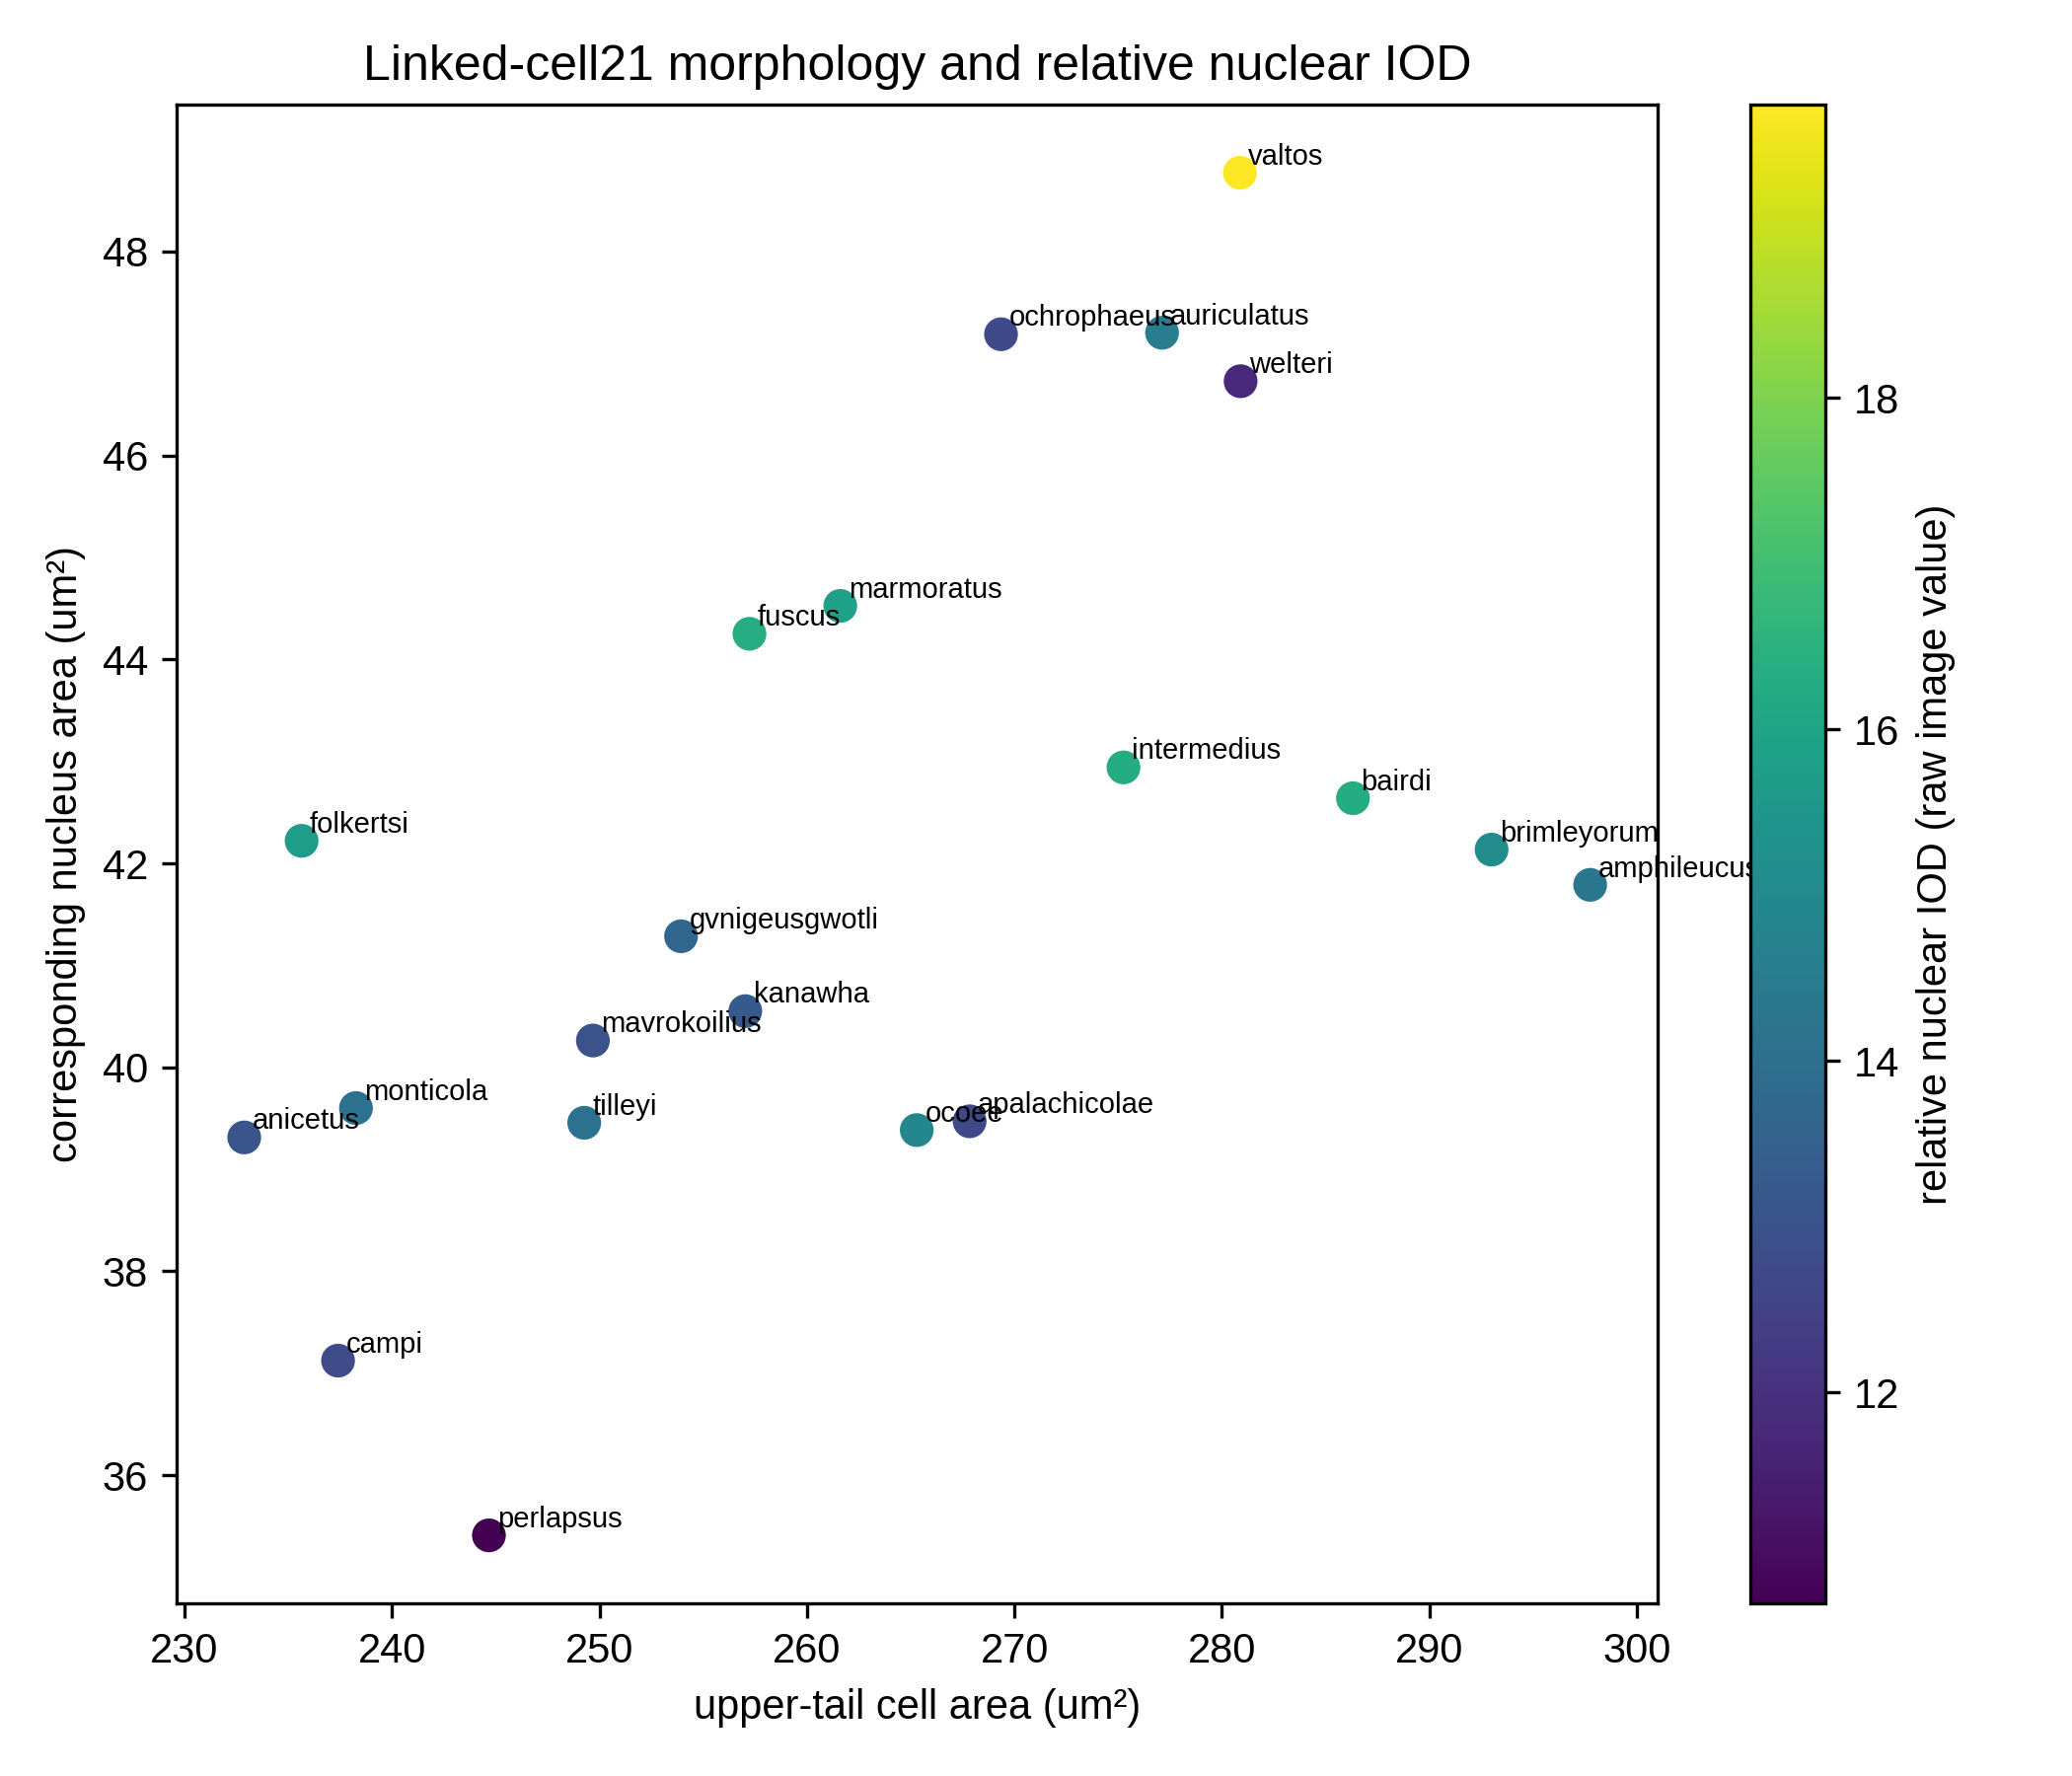

In [2]:
panel = read_csv("path_analysis/data/derived/panels/study_cell_linked_panel21_v1.csv")
traits = read_csv("results/data/corrected/cell21/cell_linked_traits_cell21_v1.csv")
assert len(panel) == 21 and panel.species.is_unique
assert len(traits) == 21 and traits.species.is_unique
assert set(panel.species) == set(traits.species)
display(traits.sort_values("cell_area_um2"))
show_figure("results/figures/corrected/cell21/cell21_cell_nucleus_relative_iod_v1.png")

## Full mask and model-review pages

In [3]:
CELL_ROOT = ROOT.parent / "cellprofiler_test"
viewer_rows = [
    ("Cell–nucleus linkage", "output/runs/mixed_cellpose_yolo_full_dataset_v1_bgclean/linkage/index.html", "linked masks and assignment QC"),
    ("Tile annotation gallery", "output/tile_annotation_bundle_v1/index.html", "training-domain annotations"),
    ("Raw / overlay / mask review", "output/tile_bootstrap_review_v1/index.html", "segmentation visual QC"),
    ("Reviewed species statistics", "output/runs/mixed_cellpose_yolo_full_dataset_v1_bgclean/linked_species_stats_reviewed/index.html", "historical diagnostic labels; inspect, do not quote pg"),
    ("Historical cell phylogenetic report", "output/runs/mixed_cellpose_yolo_full_dataset_v1_bgclean/phylogenetic_analysis/index.html", "historical diagnostic report"),
]
viewers = pd.DataFrame(viewer_rows, columns=["viewer", "relative_path", "scope"])
viewers["path"] = viewers.relative_path.map(lambda value: CELL_ROOT / value)
viewers["exists"] = viewers.path.map(Path.exists)
display(viewers[["viewer", "relative_path", "scope", "exists"]])
available_viewers = viewers[viewers.exists].copy()

def start_optional_local_viewers():
    # Start local-only HTML viewers interactively; never persist their port.
    if available_viewers.empty:
        display(Markdown(
            "The optional sibling `cellprofiler_test` HTML workspace is not present. "
            "The portable static figures below remain available."
        ))
        return None
    import functools
    import threading
    from http.server import SimpleHTTPRequestHandler, ThreadingHTTPServer
    global _cell_review_server, _cell_review_thread
    if "_cell_review_server" not in globals():
        handler = functools.partial(SimpleHTTPRequestHandler, directory=str(ROOT.parent))
        _cell_review_server = ThreadingHTTPServer(("127.0.0.1", 0), handler)
        _cell_review_thread = threading.Thread(target=_cell_review_server.serve_forever, daemon=True)
        _cell_review_thread.start()
    base = f"http://127.0.0.1:{_cell_review_server.server_address[1]}/cellprofiler_test"
    live = available_viewers.copy()
    live["url"] = live.relative_path.map(lambda value: f"{base}/{value}")
    display(HTML("".join(
        f'<p><a href="{row.url}" target="_blank"><strong>{row.viewer}</strong></a> — {row.scope}</p>'
        for row in live.itertuples()
    )))
    display(IFrame(src=live.iloc[0].url, width="100%", height=700))
    return _cell_review_server

if available_viewers.empty:
    display(Markdown(
        "**Optional local viewers unavailable.** This does not affect the portable "
        "static audit below."
    ))
else:
    display(Markdown(
        f"**Optional local viewers available: {len(available_viewers)}.** To open them "
        "during an interactive session, run `start_optional_local_viewers()`. The "
        "executed notebook intentionally saves no ephemeral localhost URL."
    ))

,viewer,relative_path,scope,exists
0,Cell–nucleus linkage,output/runs/mixed_cellpose_yolo_full_dataset_v1_bgclean/linkage/index.html,linked masks and assignment QC,True
1,Tile annotation gallery,output/tile_annotation_bundle_v1/index.html,training-domain annotations,True
2,Raw / overlay / mask review,output/tile_bootstrap_review_v1/index.html,segmentation visual QC,True
3,Reviewed species statistics,output/runs/mixed_cellpose_yolo_full_dataset_v1_bgclean/linked_species_stats_reviewed/index.html,"historical diagnostic labels; inspect, do not quote pg",True
4,Historical cell phylogenetic report,output/runs/mixed_cellpose_yolo_full_dataset_v1_bgclean/phylogenetic_analysis/index.html,historical diagnostic report,True


**Optional local viewers available: 5.** To open them during an interactive session, run `start_optional_local_viewers()`. The executed notebook intentionally saves no ephemeral localhost URL.

## Static mask examples and segmentation/support diagnostics

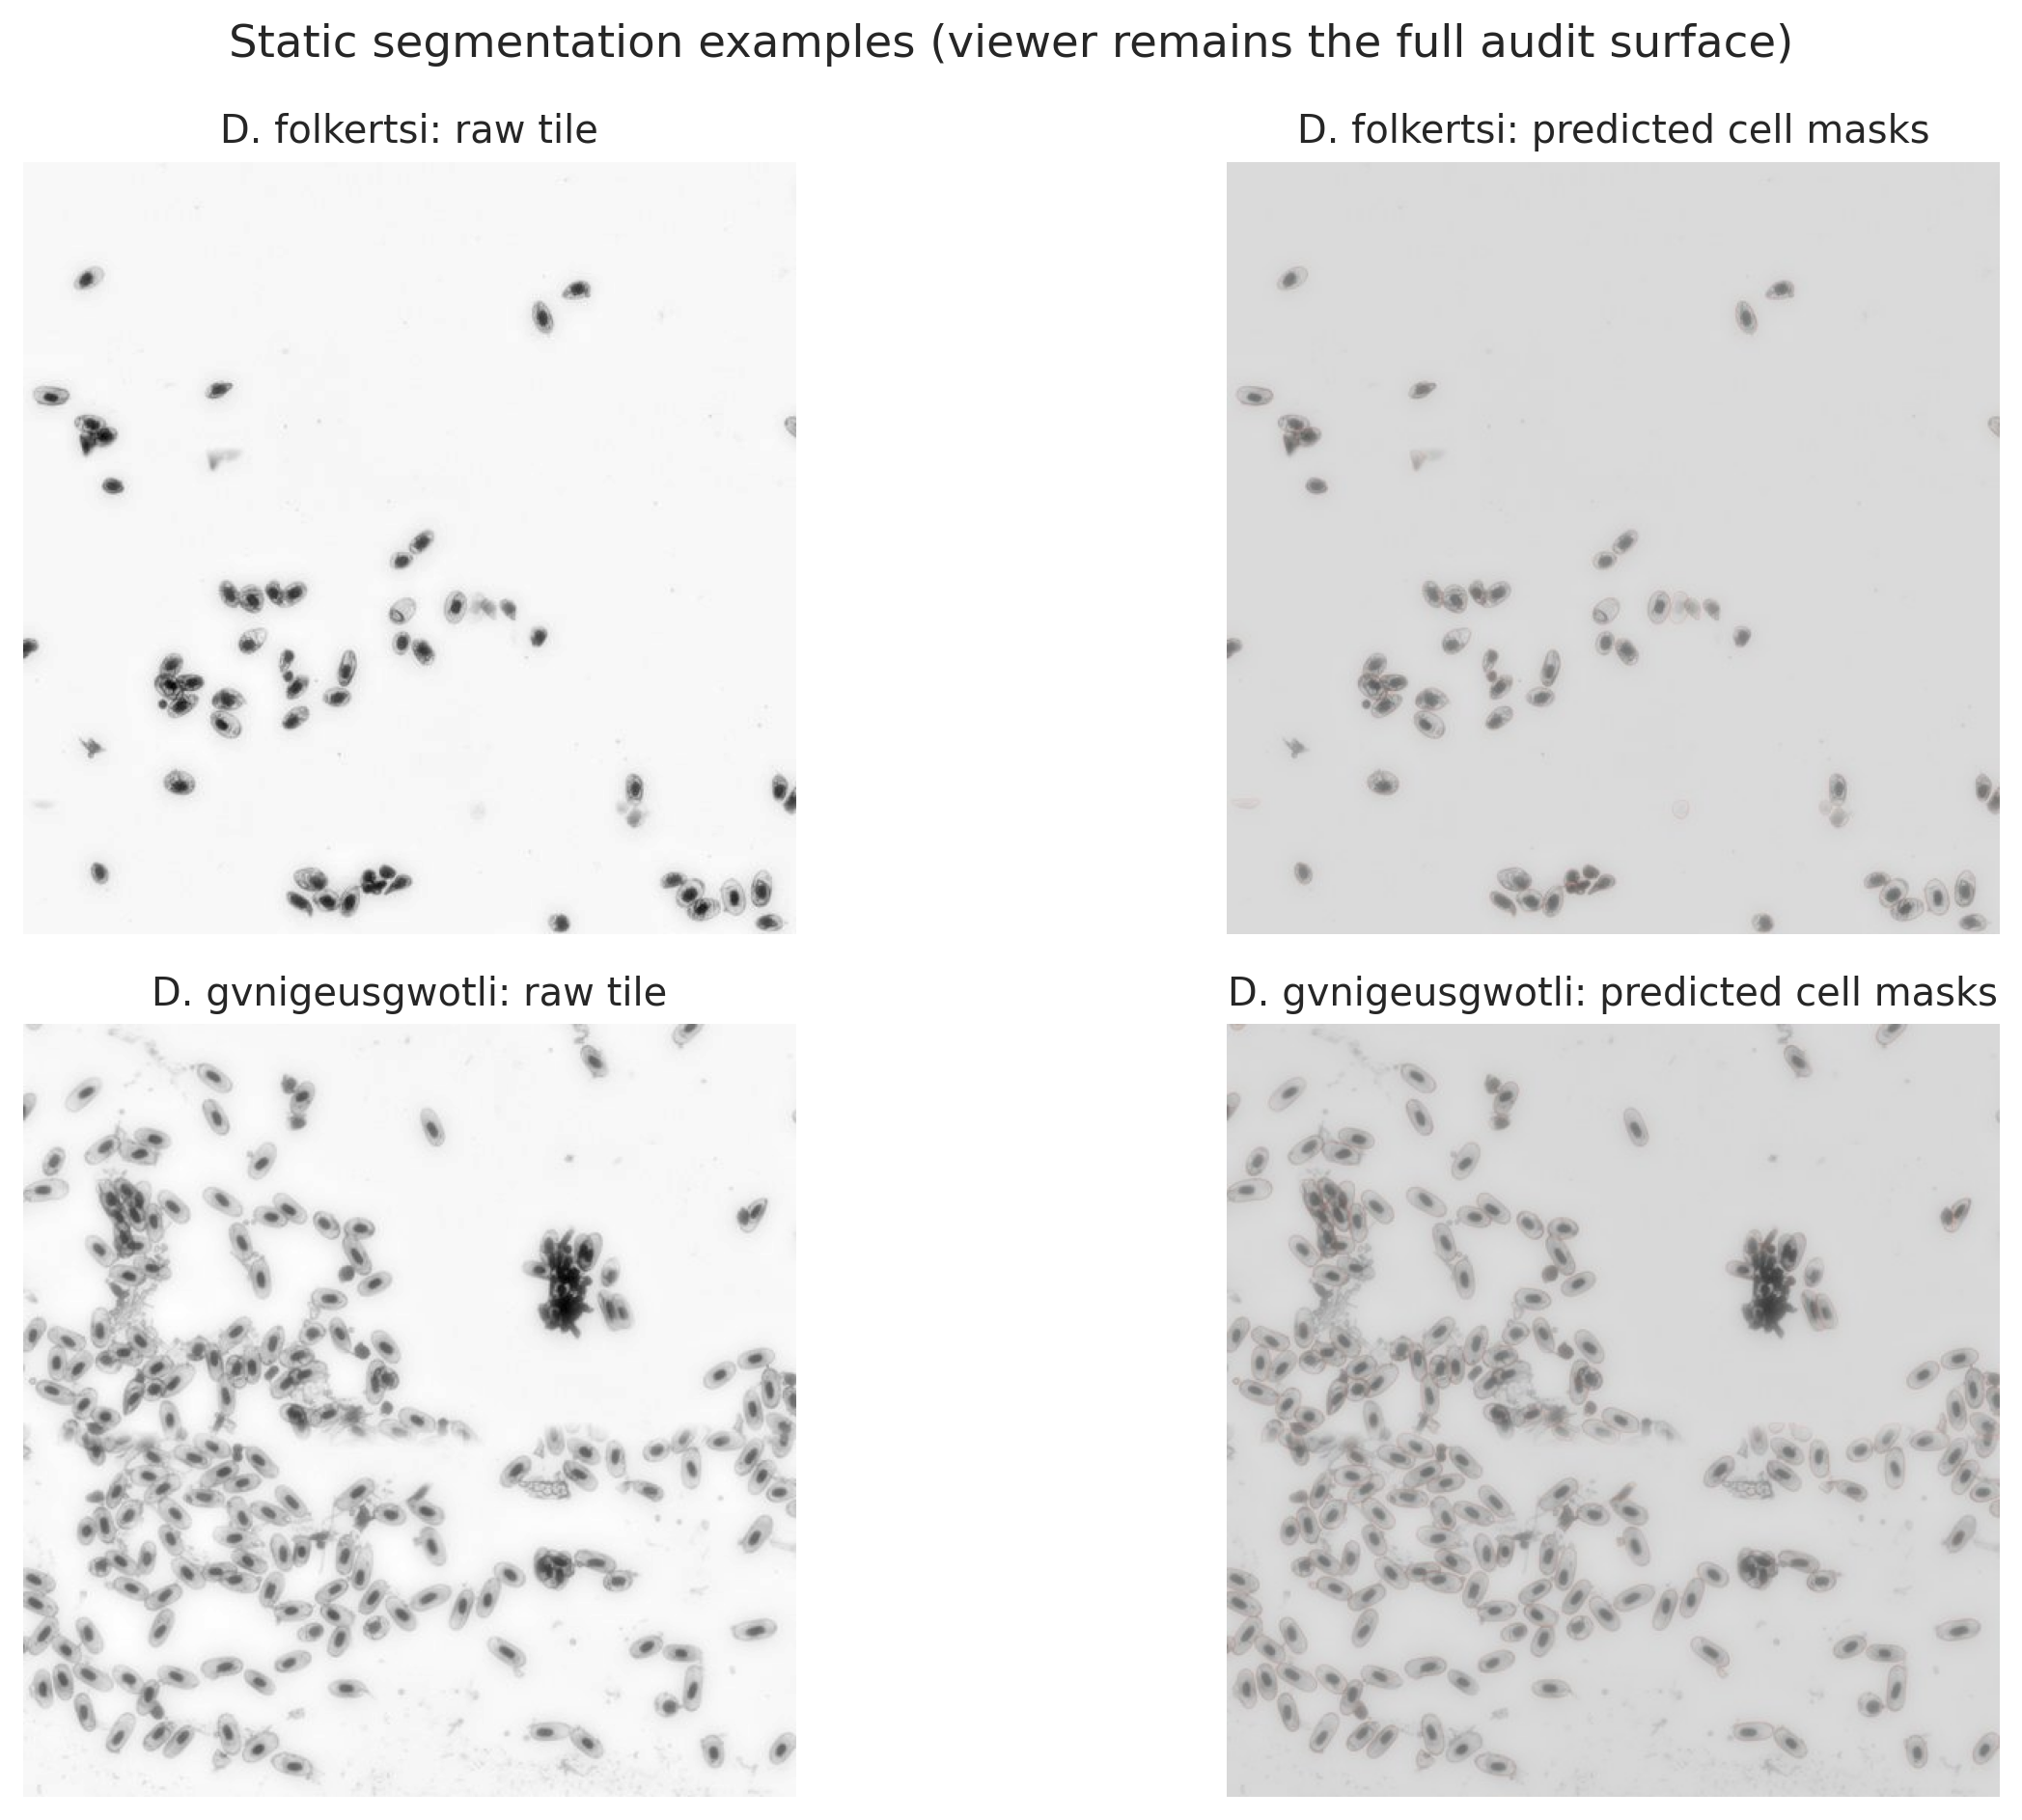

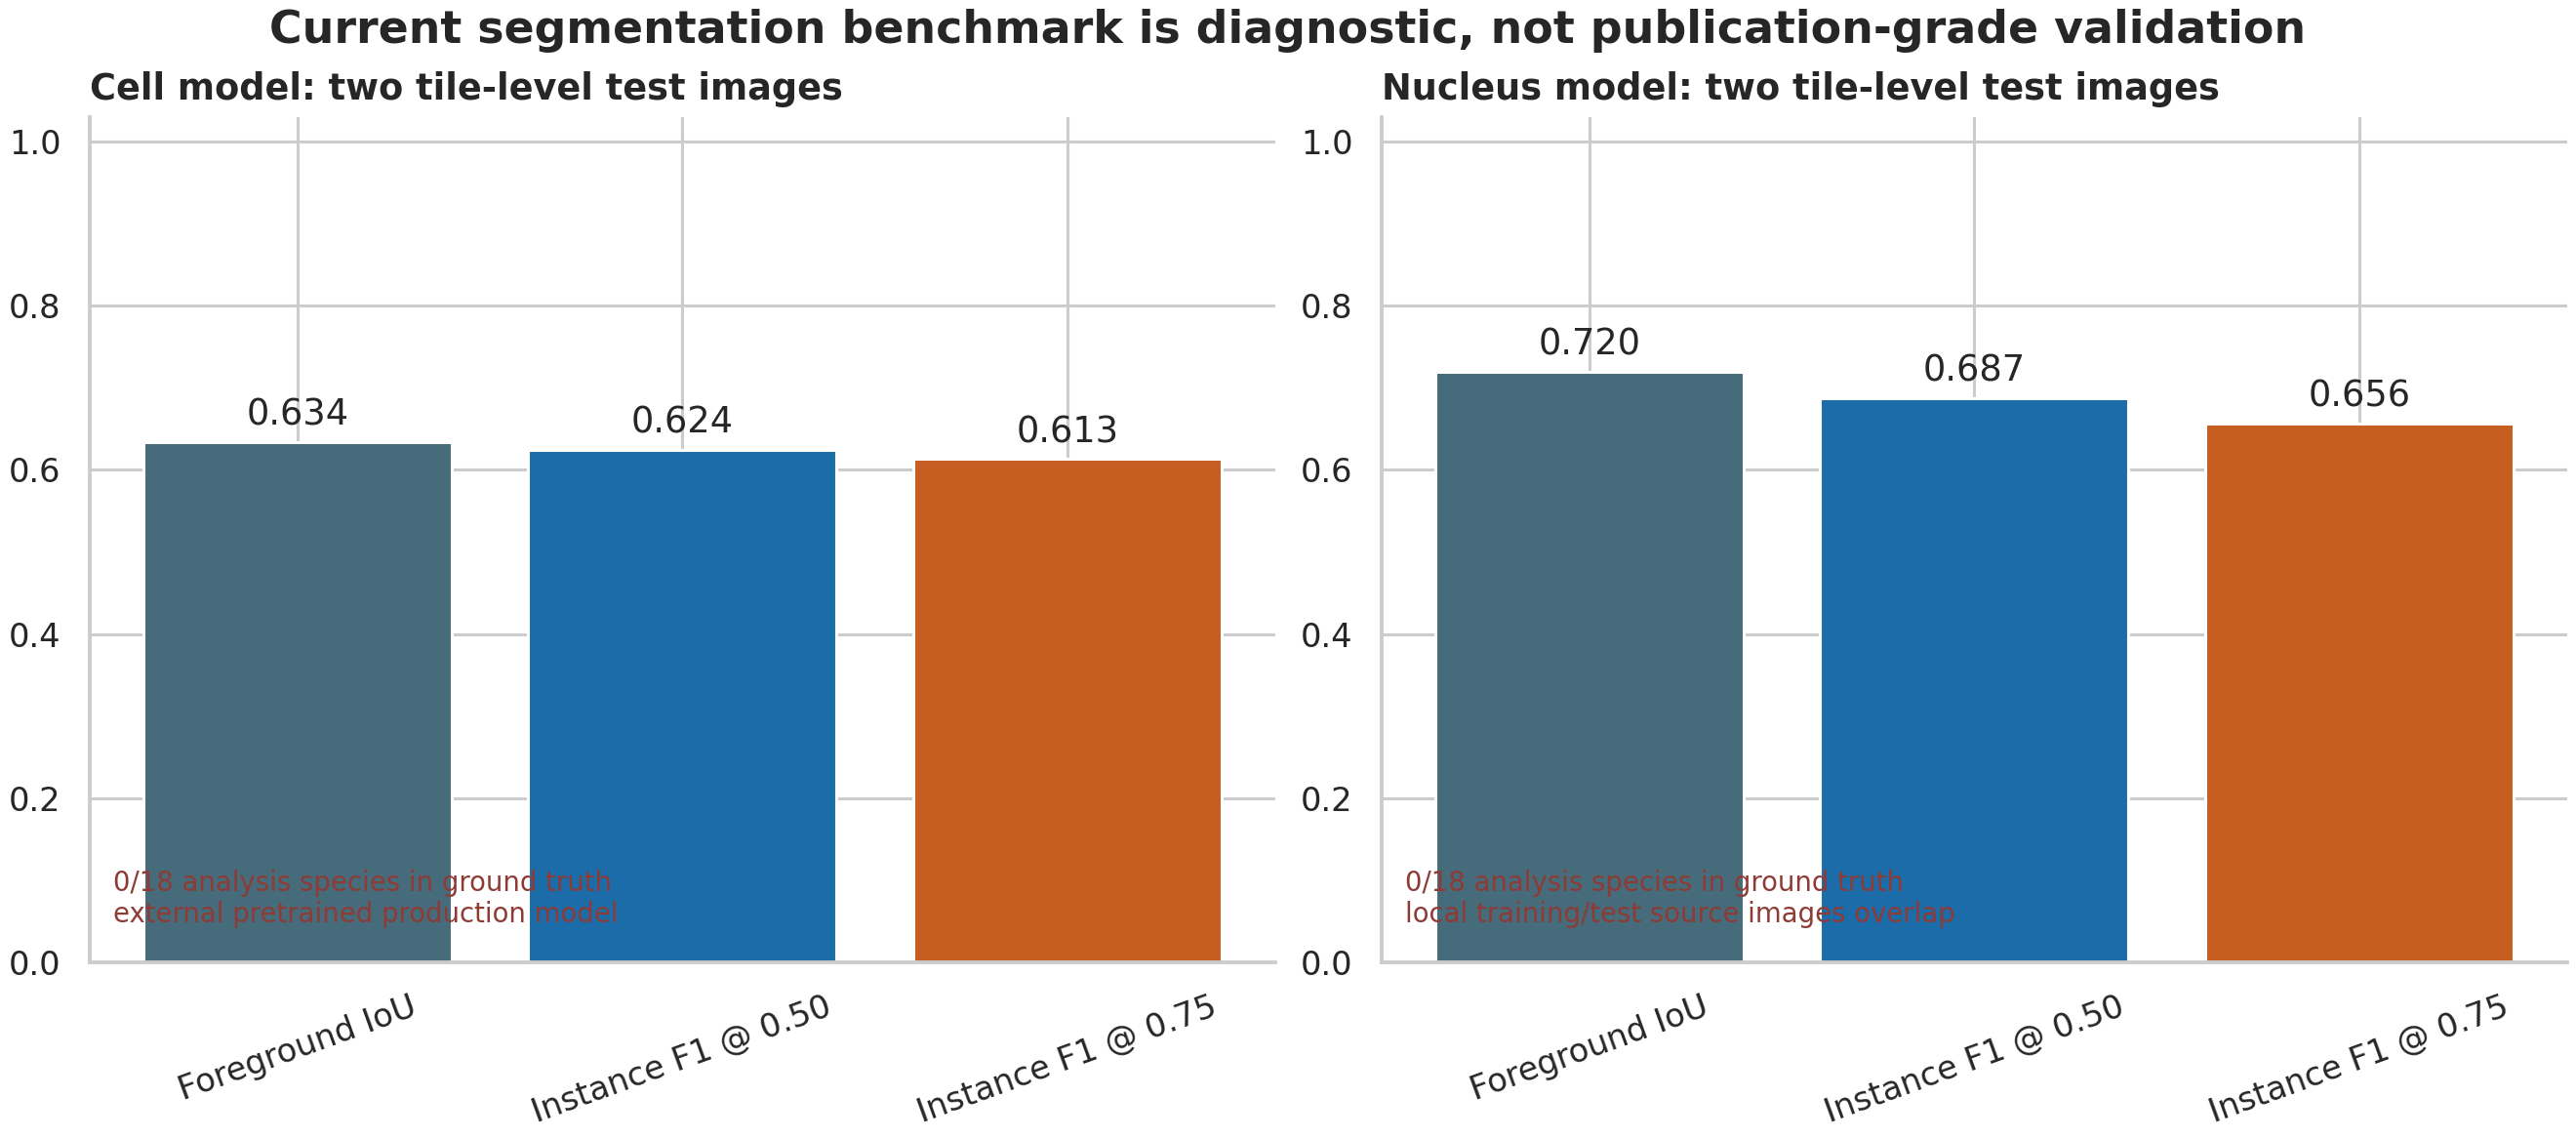

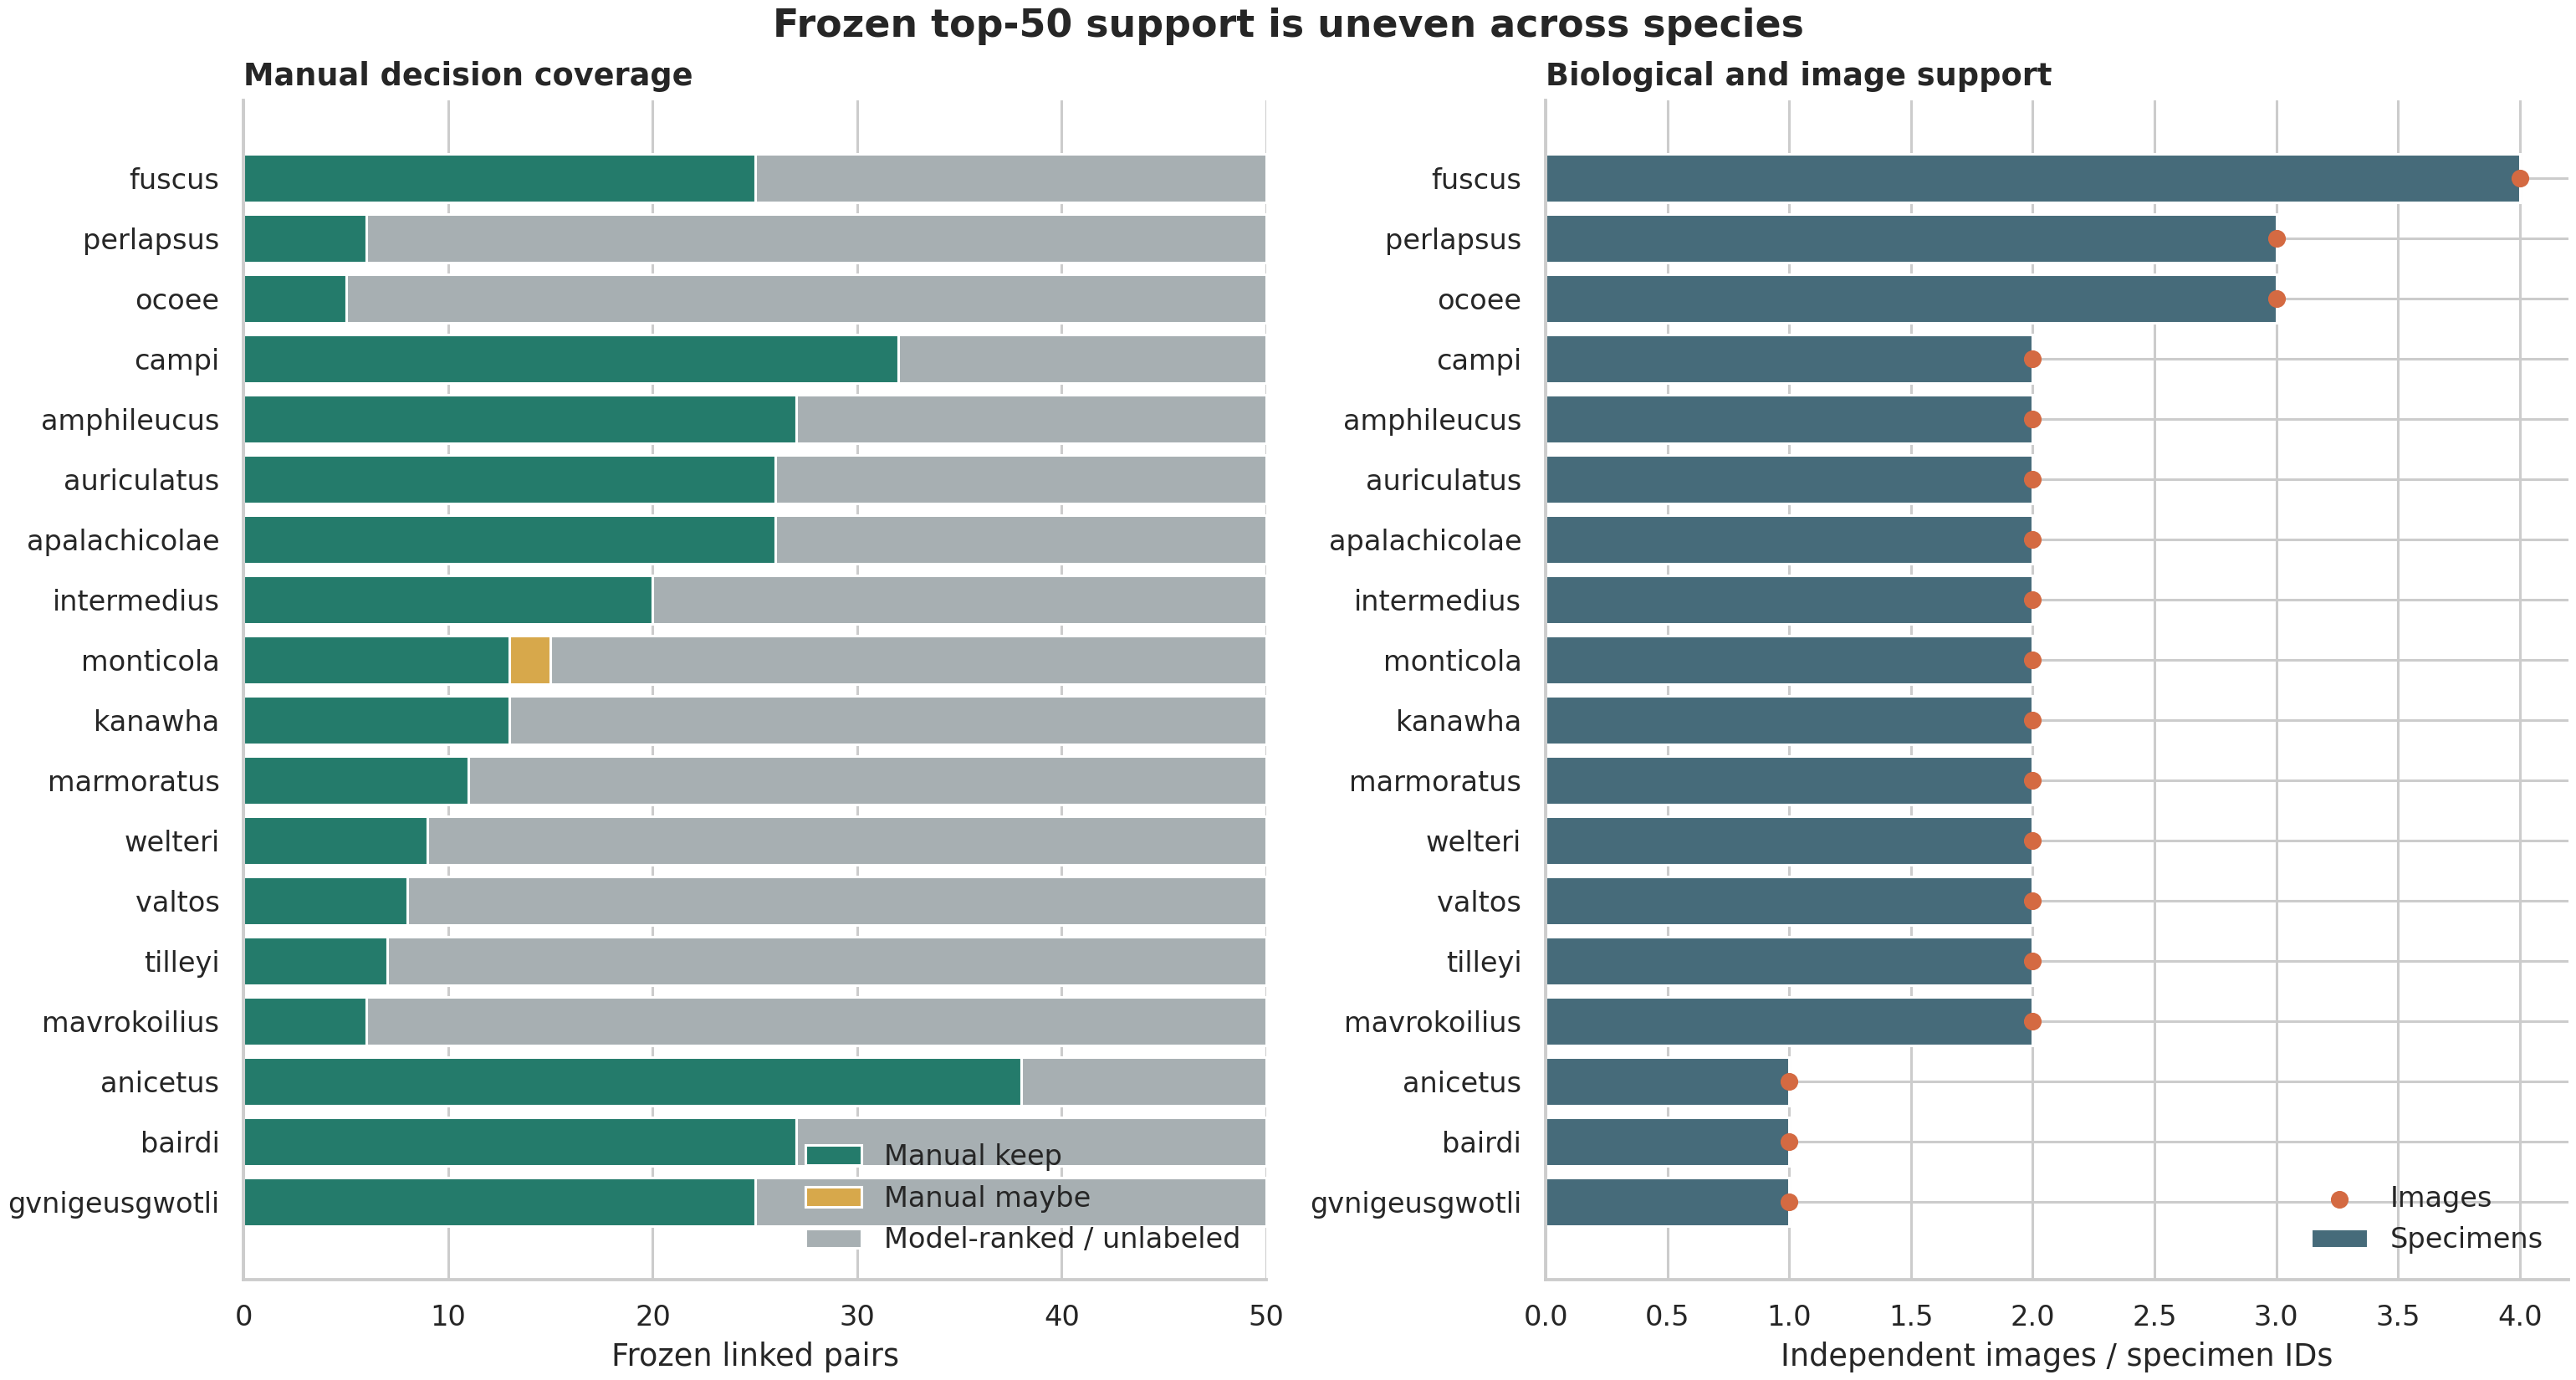

,task,training_manifest,benchmark_directory,n_training_tiles_in_annotation_manifest,n_local_training_tiles_used_by_production_model,n_test_tiles,n_training_objects_recorded_in_manifest,n_test_objects_recorded_in_manifest,training_species,test_species,n_training_species,n_test_species,source_image_overlap_train_test,species_overlap_train_test,production_model_uses_local_training,production_model_training_source,n_final18_species_in_training,n_final18_species_in_test,heldout_unit,status,n_images_scored,n_gt_objects,test_manifest_minus_scored_gt_objects,n_pred_objects,foreground_iou,foreground_dice,precision_50,recall_50,f1_50,precision_75,recall_75,f1_75,object_count_bias_pct,foreground_area_bias_pct,median_absolute_count_error_per_tile,publication_validation_status,reason
0,cell,/home/jake/Projects/cellprofiler_test/output/tile_training_round_v1/training_manifest.csv,/home/jake/Projects/cellprofiler_test/output/benchmarks/archived_production_cell_masks_tile_holdout_v1,10,0,2,350,138,folkertsi;ochrophaeus,folkertsi;ochrophaeus,2,2,Process_316_raw_green.ome.tiff;Process_366_raw_green.ome.tiff,folkertsi;ochrophaeus,False,external_Cellpose_cpsam_pretraining,0,0,tile_only,ok,2,138,0,224,0.633945,0.775968,0.504464,0.818841,0.624309,0.495536,0.804348,0.61326,62.318841,13.284147,43,not_approved,Only two tile-level test images from two excluded species; no final-18 analysis species occurs in ground truth. Prod...
1,nucleus,/home/jake/Projects/cellprofiler_test/output/nucleus_label_manual_round1/manifest.csv,/home/jake/Projects/cellprofiler_test/output/benchmarks/current_models_tile_holdout_v1_nucleus,10,10,2,350,138,folkertsi;ochrophaeus,folkertsi;ochrophaeus,2,2,Process_316_raw_green.ome.tiff;Process_366_raw_green.ome.tiff,folkertsi;ochrophaeus,True,local_manual_tiles,0,0,tile_only,ok,2,243,-105,147,0.719690,0.837000,0.911565,0.551440,0.687179,0.870748,0.526749,0.65641,-39.506173,-4.194966,48,not_approved,Only two tile-level test images; source images and species overlap local training; no final-18 analysis species occu...


In [4]:
show_figure("results/figures/presentation_notebooks/cell_models/cell_mask_examples_analysis18_v1.png")
show_figure("results/figures/corrected/microscopy/microscopy_segmentation_validation_analysis18_v1.png")
show_figure("results/figures/corrected/microscopy/microscopy_support_and_review_analysis18_v1.png")
validation = read_csv("results/data/corrected/microscopy/microscopy_segmentation_validation_analysis18_v1.csv")
display(validation)

## Largest-50 estimand and selection-depth sensitivity

,species,estimator,estimator_label,metric,metric_label,estimate,n_pairs,n_images,n_specimens,estimand
0,amphileucus,composite_selected50,Frozen composite top 50,cell_area_um2,Cell area (um2),297.129600,50,2,2,median among frozen composite top 50
1,amphileucus,composite_selected50,Frozen composite top 50,nuc_area_um2,Nucleus area (um2),41.659200,50,2,2,median among frozen composite top 50
2,amphileucus,composite_selected50,Frozen composite top 50,nc_area_ratio,Nucleus/cell area ratio,0.139244,50,2,2,median among frozen composite top 50
3,amphileucus,image_balanced_selected50,Equal-image frozen top 50,cell_area_um2,Cell area (um2),296.964000,50,2,2,equal-image median of within-image medians among frozen composite top-50 rows
4,amphileucus,image_balanced_selected50,Equal-image frozen top 50,nuc_area_um2,Nucleus area (um2),41.709600,50,2,2,equal-image median of within-image medians among frozen composite top-50 rows
...,...,...,...,...,...,...,...,...,...,...
319,welteri,eligible_candidate_pool,All eligible candidates,nuc_area_um2,Nucleus area (um2),44.409600,285,4,2,median among all eligible candidates
320,welteri,eligible_candidate_pool,All eligible candidates,nc_area_ratio,Nucleus/cell area ratio,0.175663,285,4,2,median among all eligible candidates
321,welteri,manual_keep_pool,Manual keeps,cell_area_um2,Cell area (um2),281.649600,9,2,2,median among manual keeps
322,welteri,manual_keep_pool,Manual keeps,nuc_area_um2,Nucleus area (um2),45.158400,9,2,2,median among manual keeps


,metric,estimator_left,estimator_right,spearman_rho,spearman_p,n_species,median_pct_shift_right_vs_left,maximum_absolute_pct_shift
0,cell_area_um2,composite_selected50,image_balanced_selected50,0.952528,1.116959e-09,18,-0.027867,4.206646
1,cell_area_um2,composite_selected50,literal_largest50_eligible,0.944272,3.923997e-09,18,4.036492,7.889924
2,cell_area_um2,composite_selected50,literal_largest100_eligible,0.960784,2.486567e-10,18,0.212838,6.113362
3,cell_area_um2,composite_selected50,eligible_candidate_pool,0.865841,3.434511e-06,18,-11.638049,16.733281
4,cell_area_um2,composite_selected50,manual_keep_pool,0.698658,1.257534e-03,18,1.519921,14.270869
5,cell_area_um2,image_balanced_selected50,literal_largest50_eligible,0.923633,4.568457e-08,18,4.173480,12.627776
6,cell_area_um2,image_balanced_selected50,literal_largest100_eligible,0.940144,6.859458e-09,18,0.530919,6.113362
7,cell_area_um2,image_balanced_selected50,eligible_candidate_pool,0.841073,1.227137e-05,18,-10.833288,15.326307
8,cell_area_um2,image_balanced_selected50,manual_keep_pool,0.742002,4.226652e-04,18,1.060500,14.045090
9,cell_area_um2,literal_largest50_eligible,literal_largest100_eligible,0.983488,2.638289e-13,18,-3.909294,7.258170


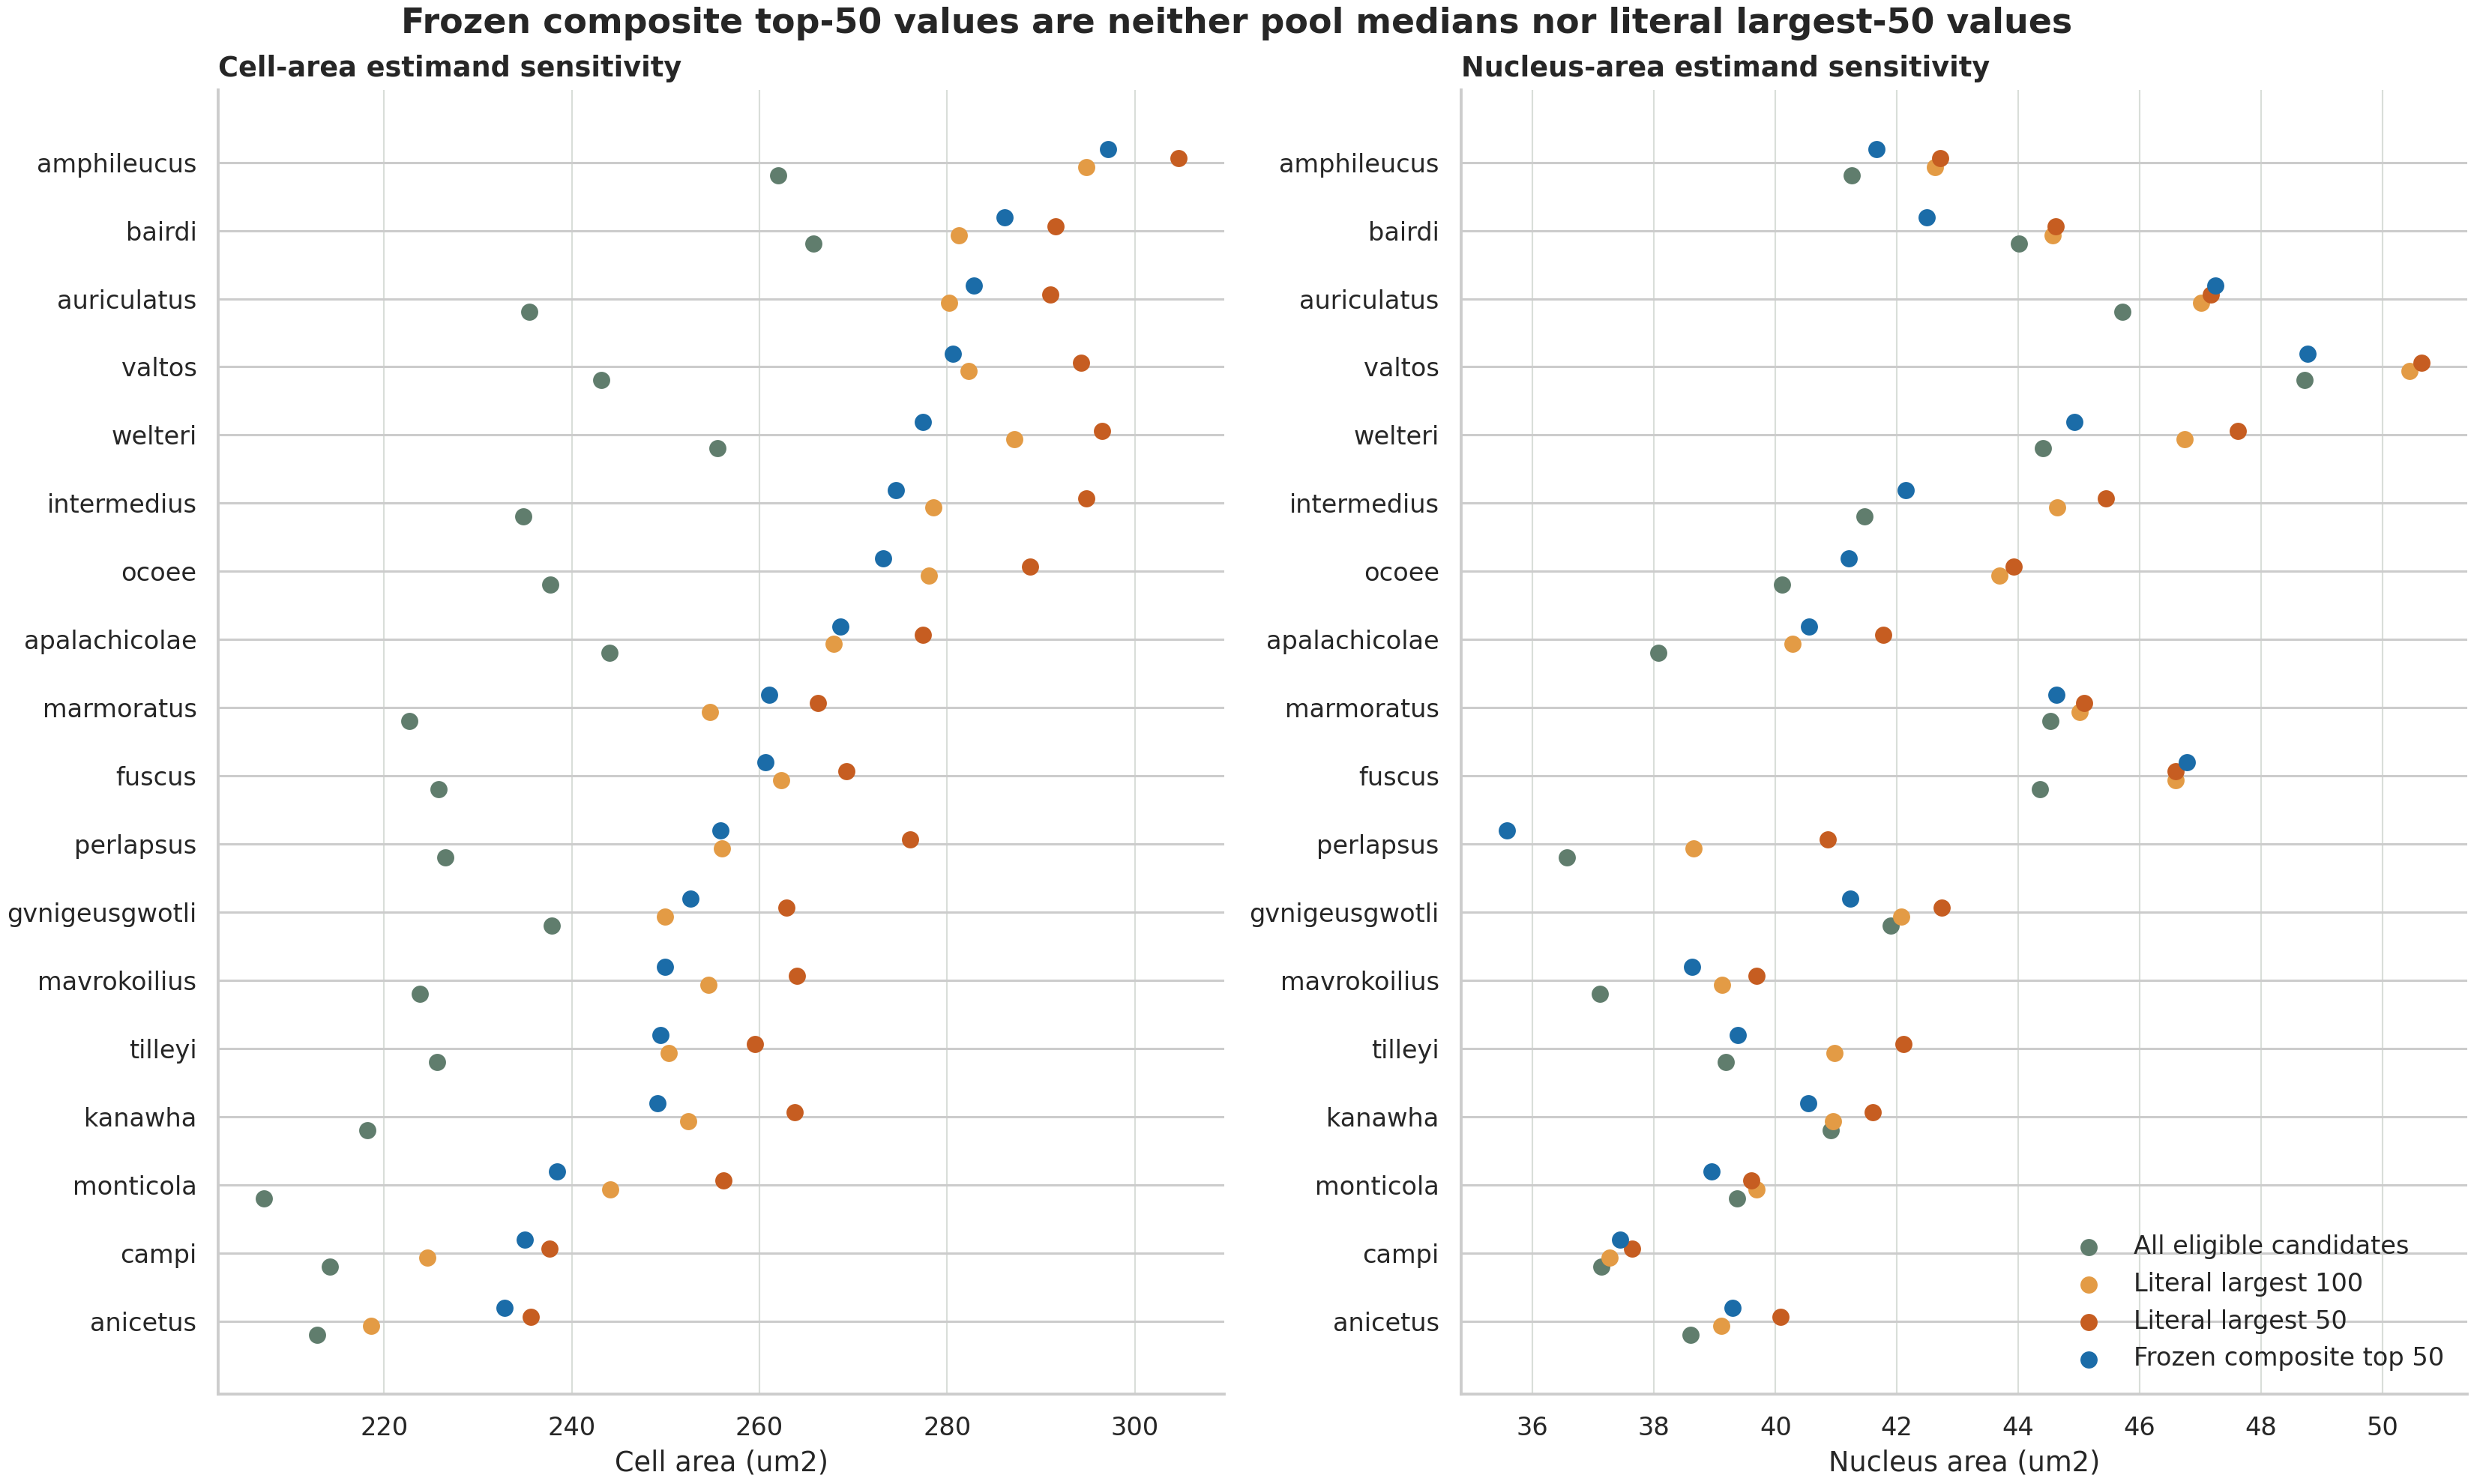

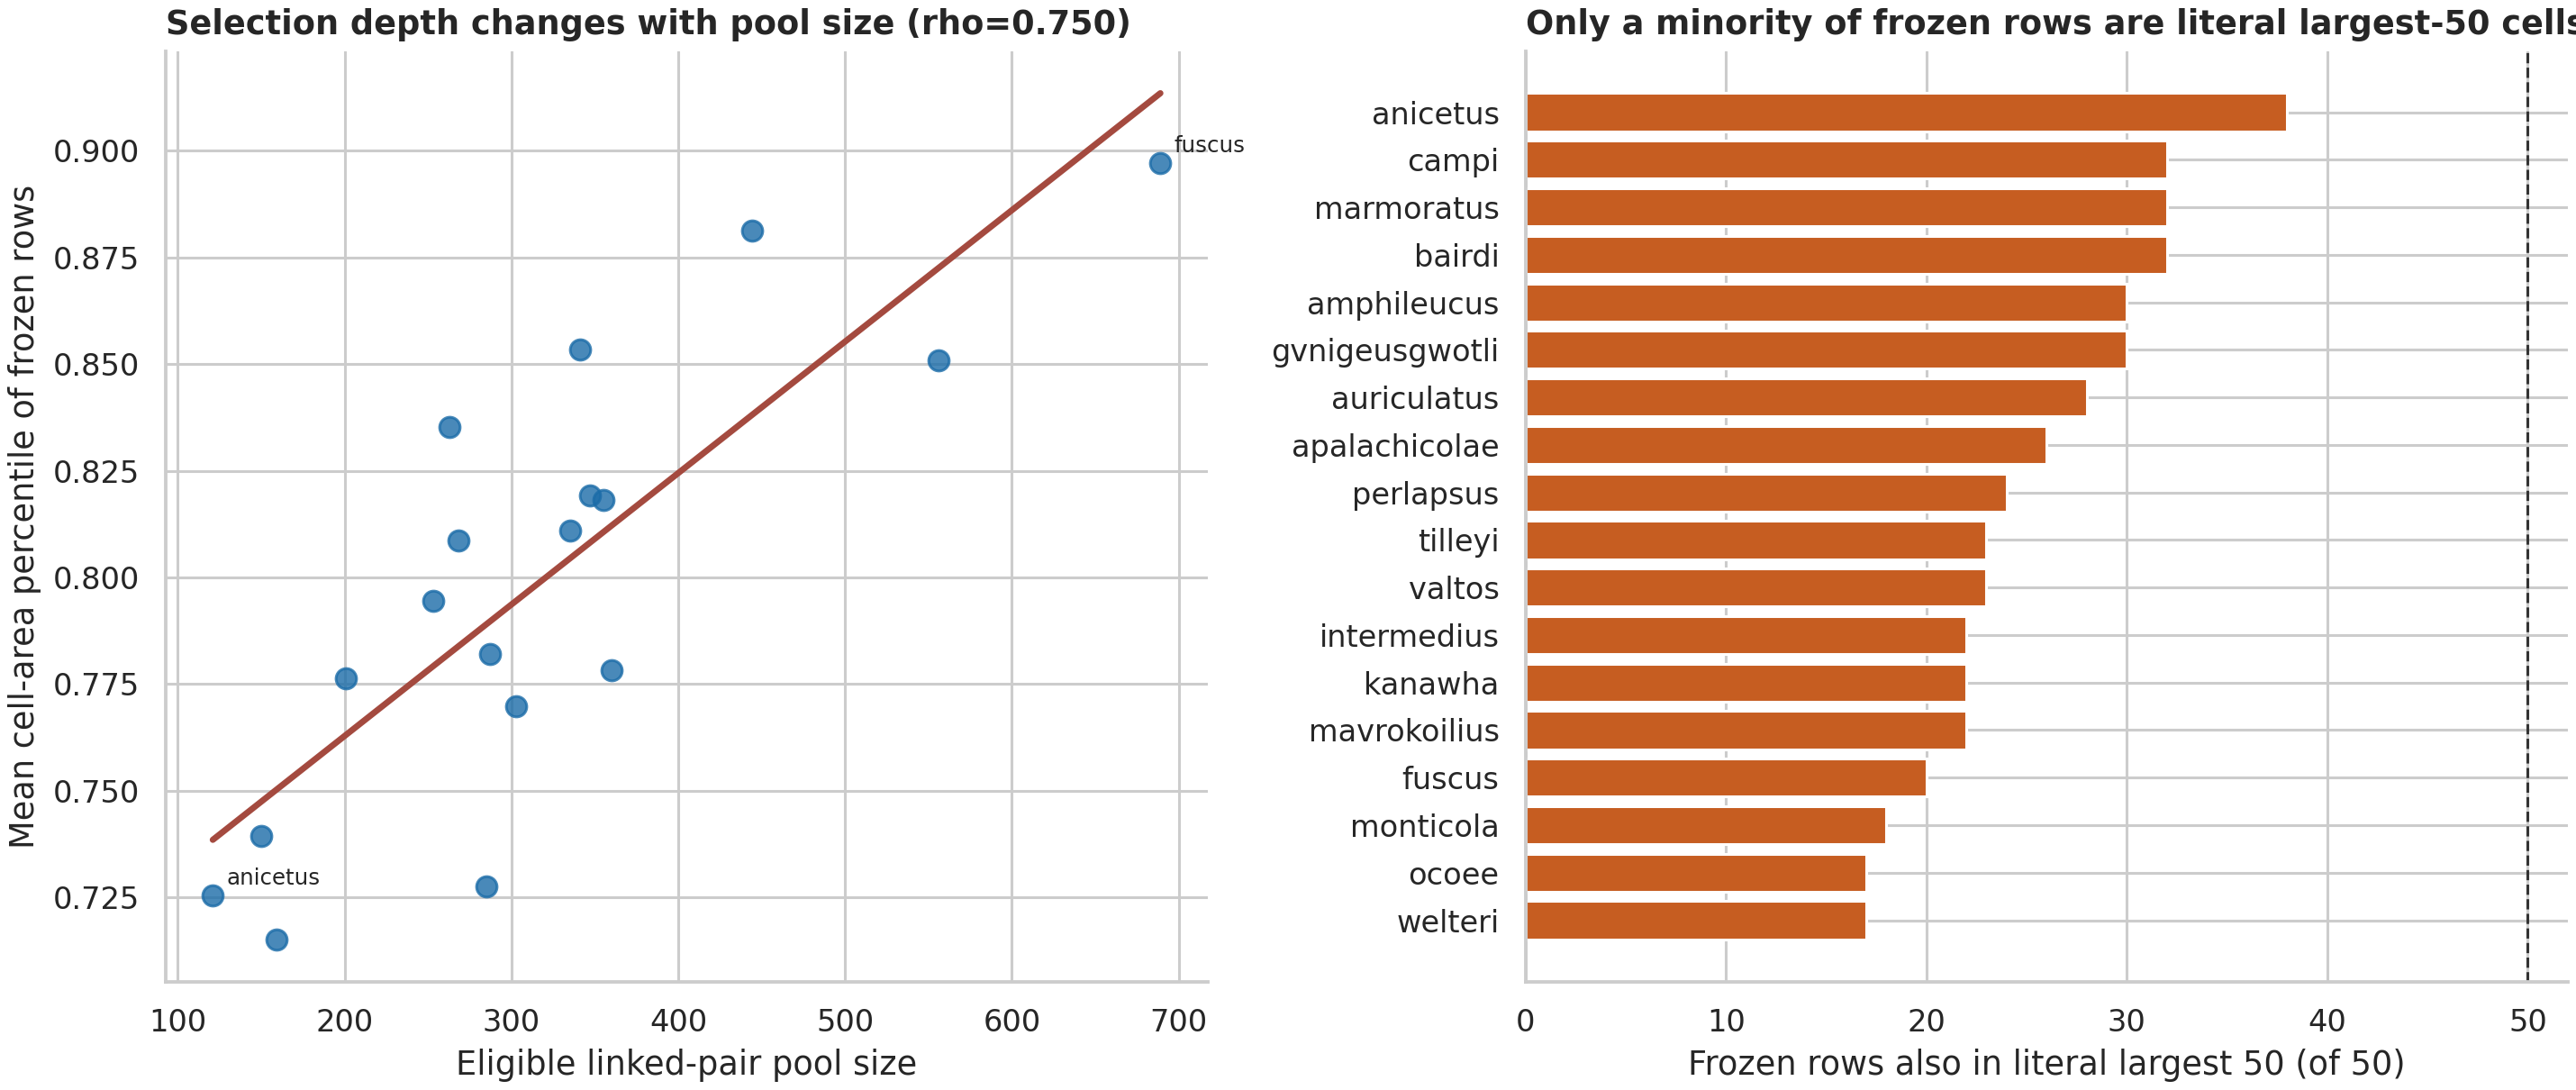

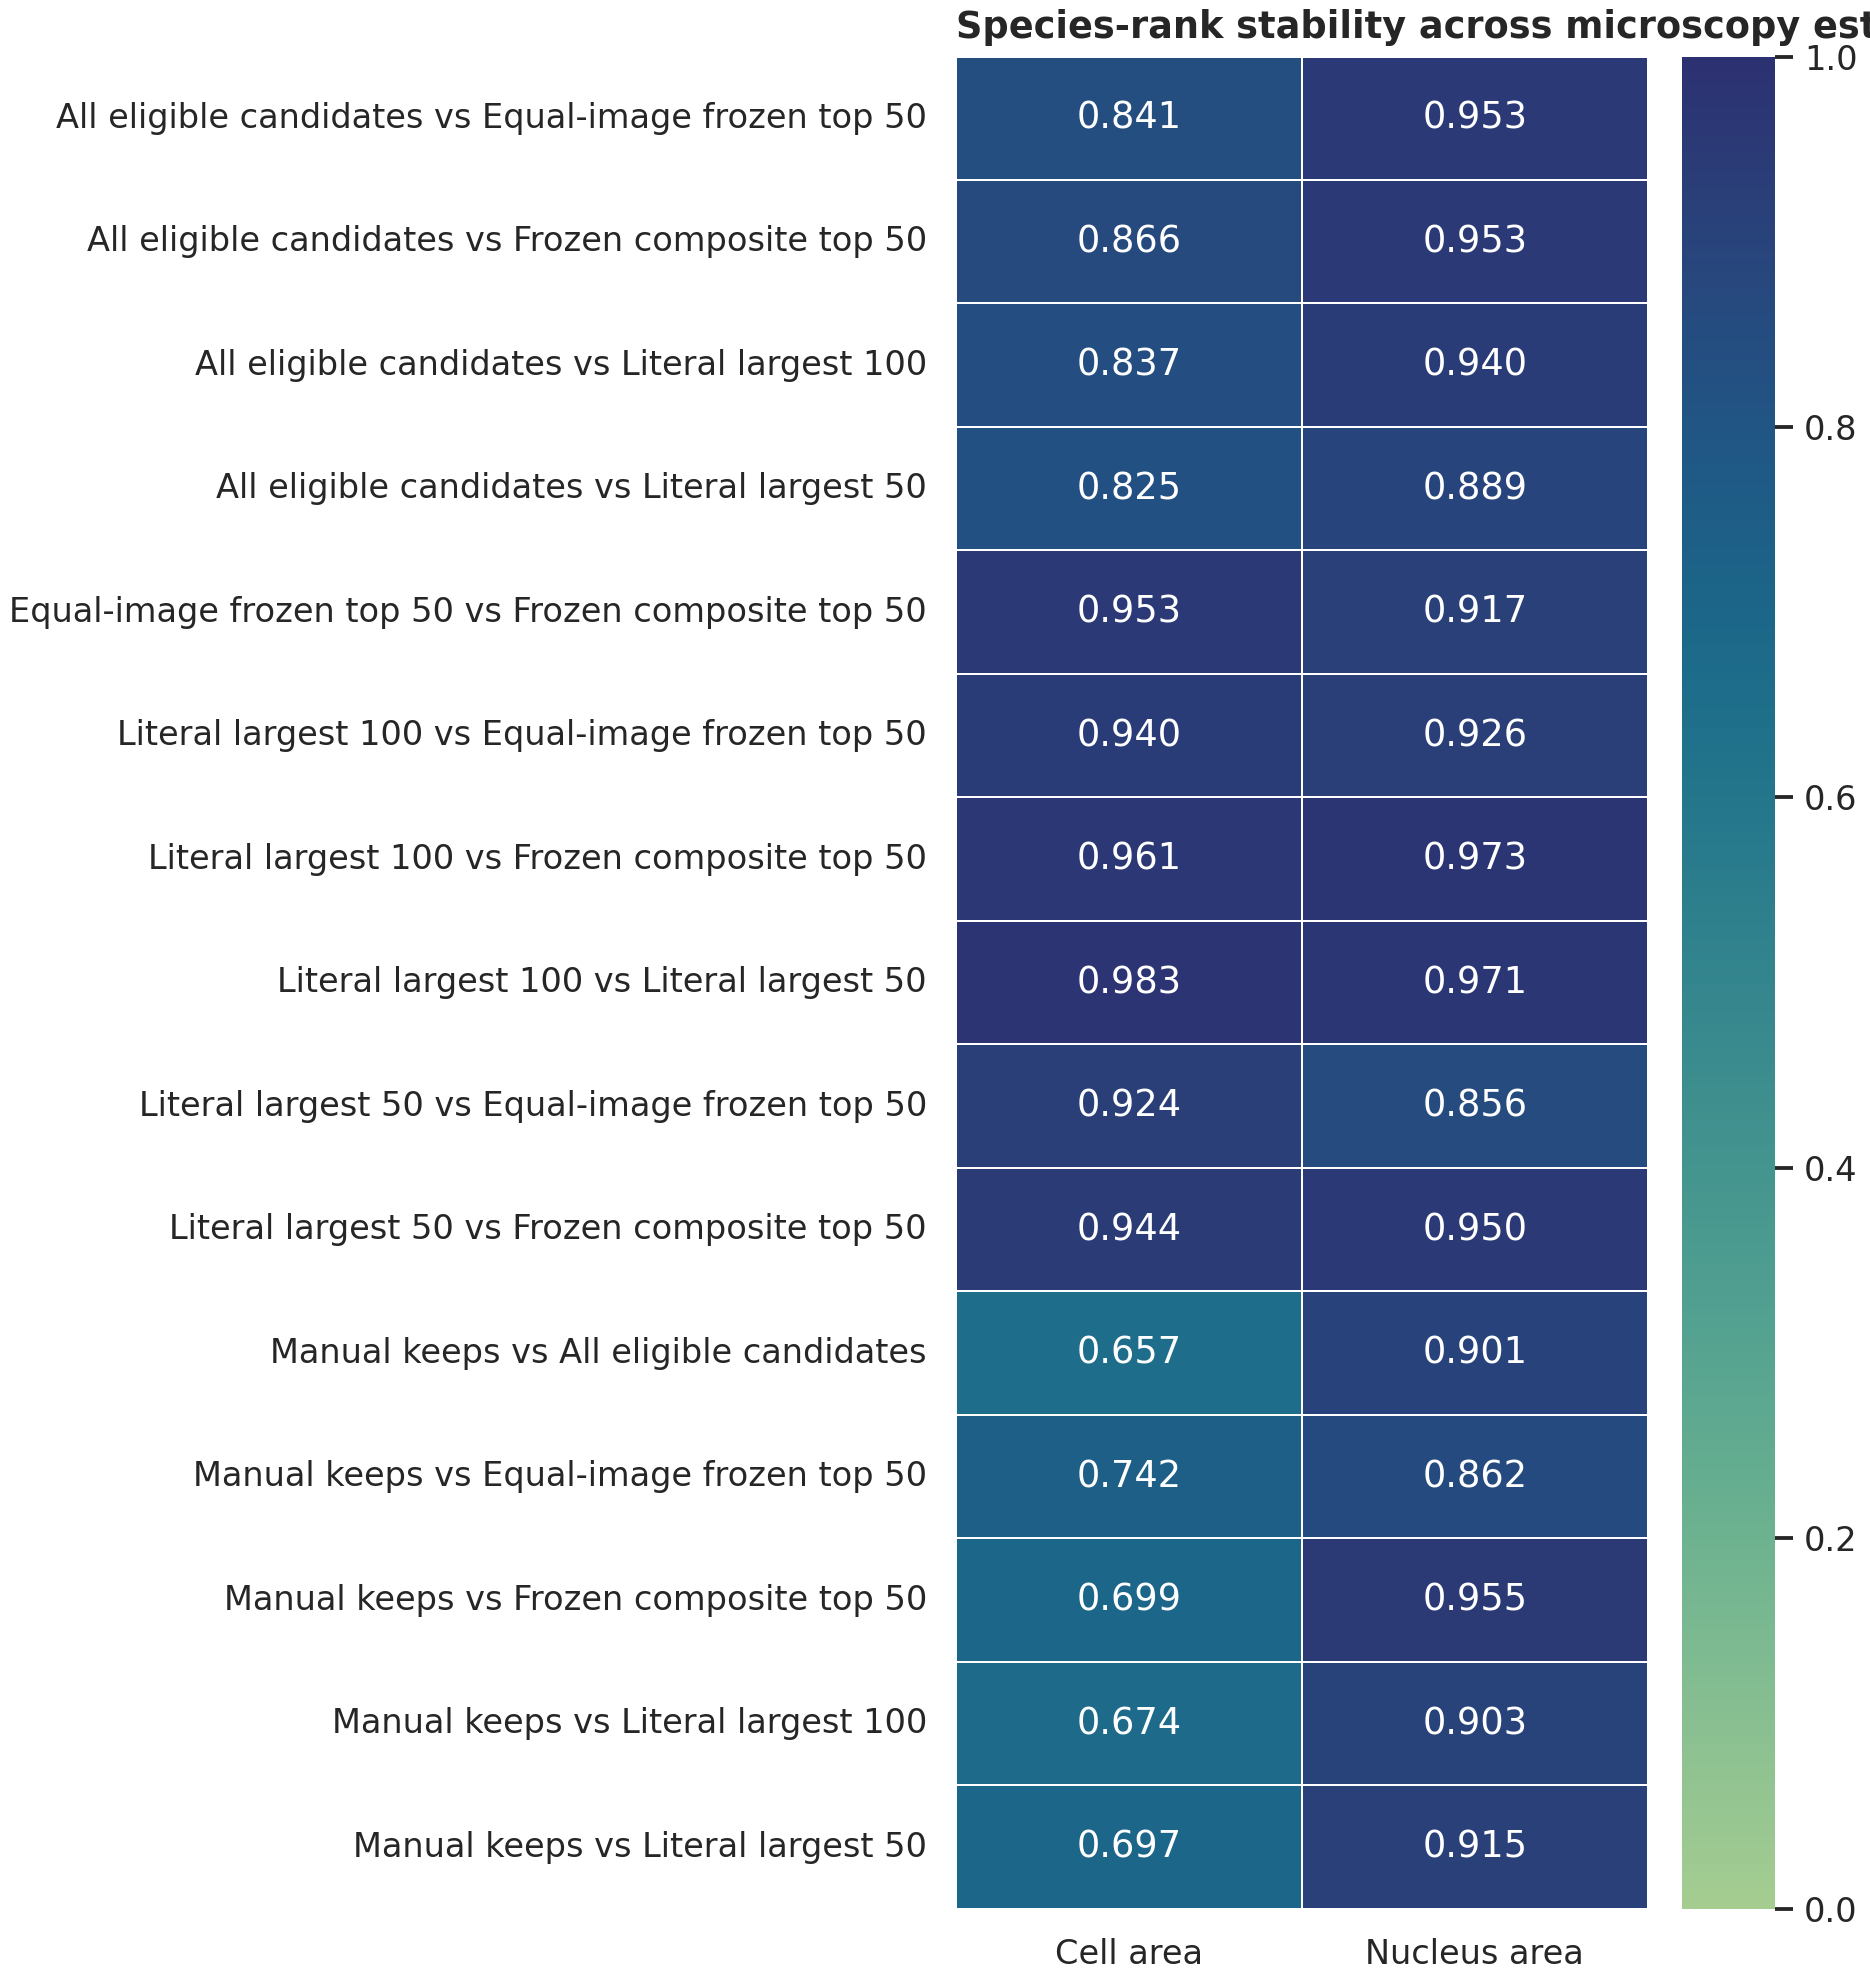

In [5]:
estimands = read_csv("results/data/corrected/microscopy/microscopy_estimand_sensitivity_analysis18_v1.csv")
stability = read_csv("results/data/corrected/microscopy/microscopy_estimator_rank_stability_analysis18_v1.csv")
display(estimands)
display(stability)
show_figure("results/figures/corrected/microscopy/microscopy_estimand_sensitivity_analysis18_v1.png")
show_figure("results/figures/corrected/microscopy/microscopy_selection_depth_analysis18_v1.png")
show_figure("results/figures/corrected/microscopy/microscopy_estimator_rank_stability_analysis18_v1.png")

## Pairwise traits and phylogenetic tracks

The next two frozen figures use the path18 overlap because they require the exact
comparative tree and complete integrated traits. They do not redefine the Cell21
descriptive panel. Raw species points, phylogenetic sensitivity, and standardized
tree tracks are shown together.

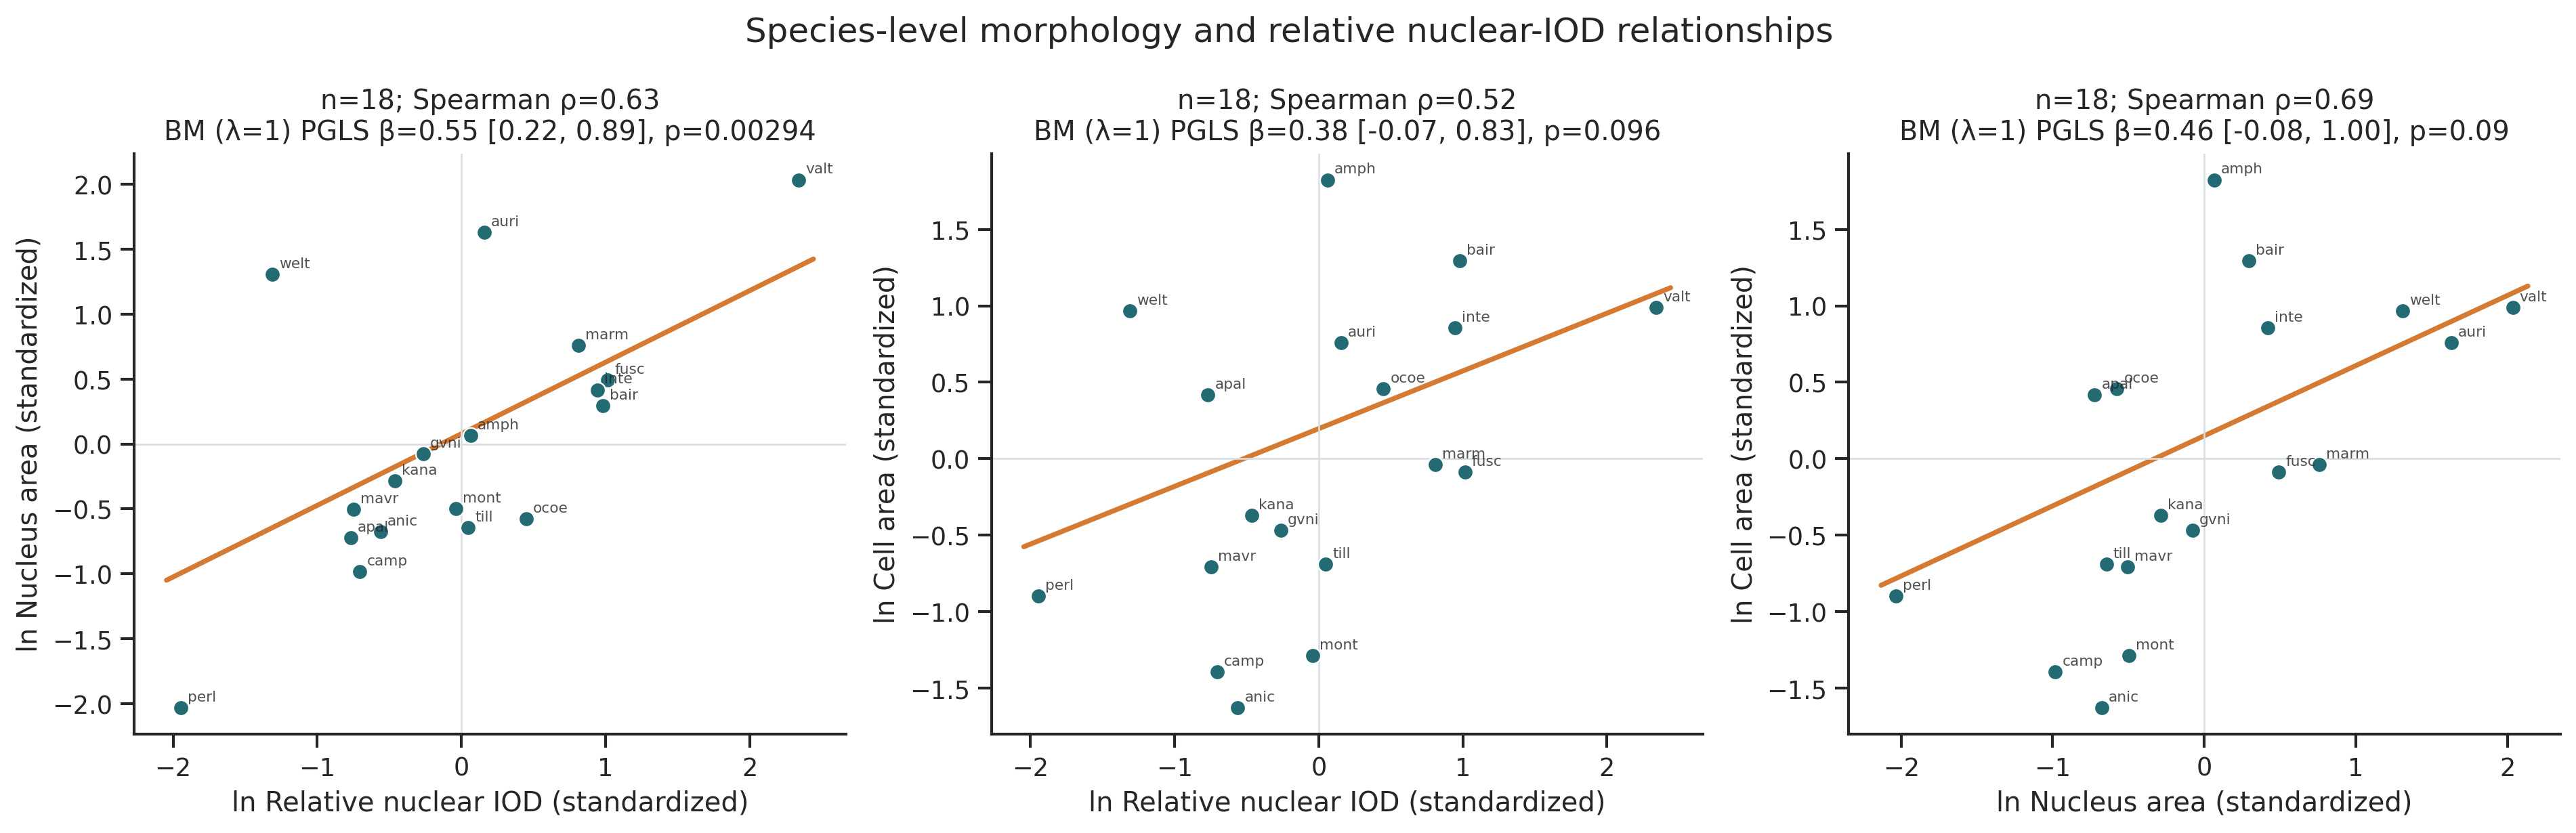

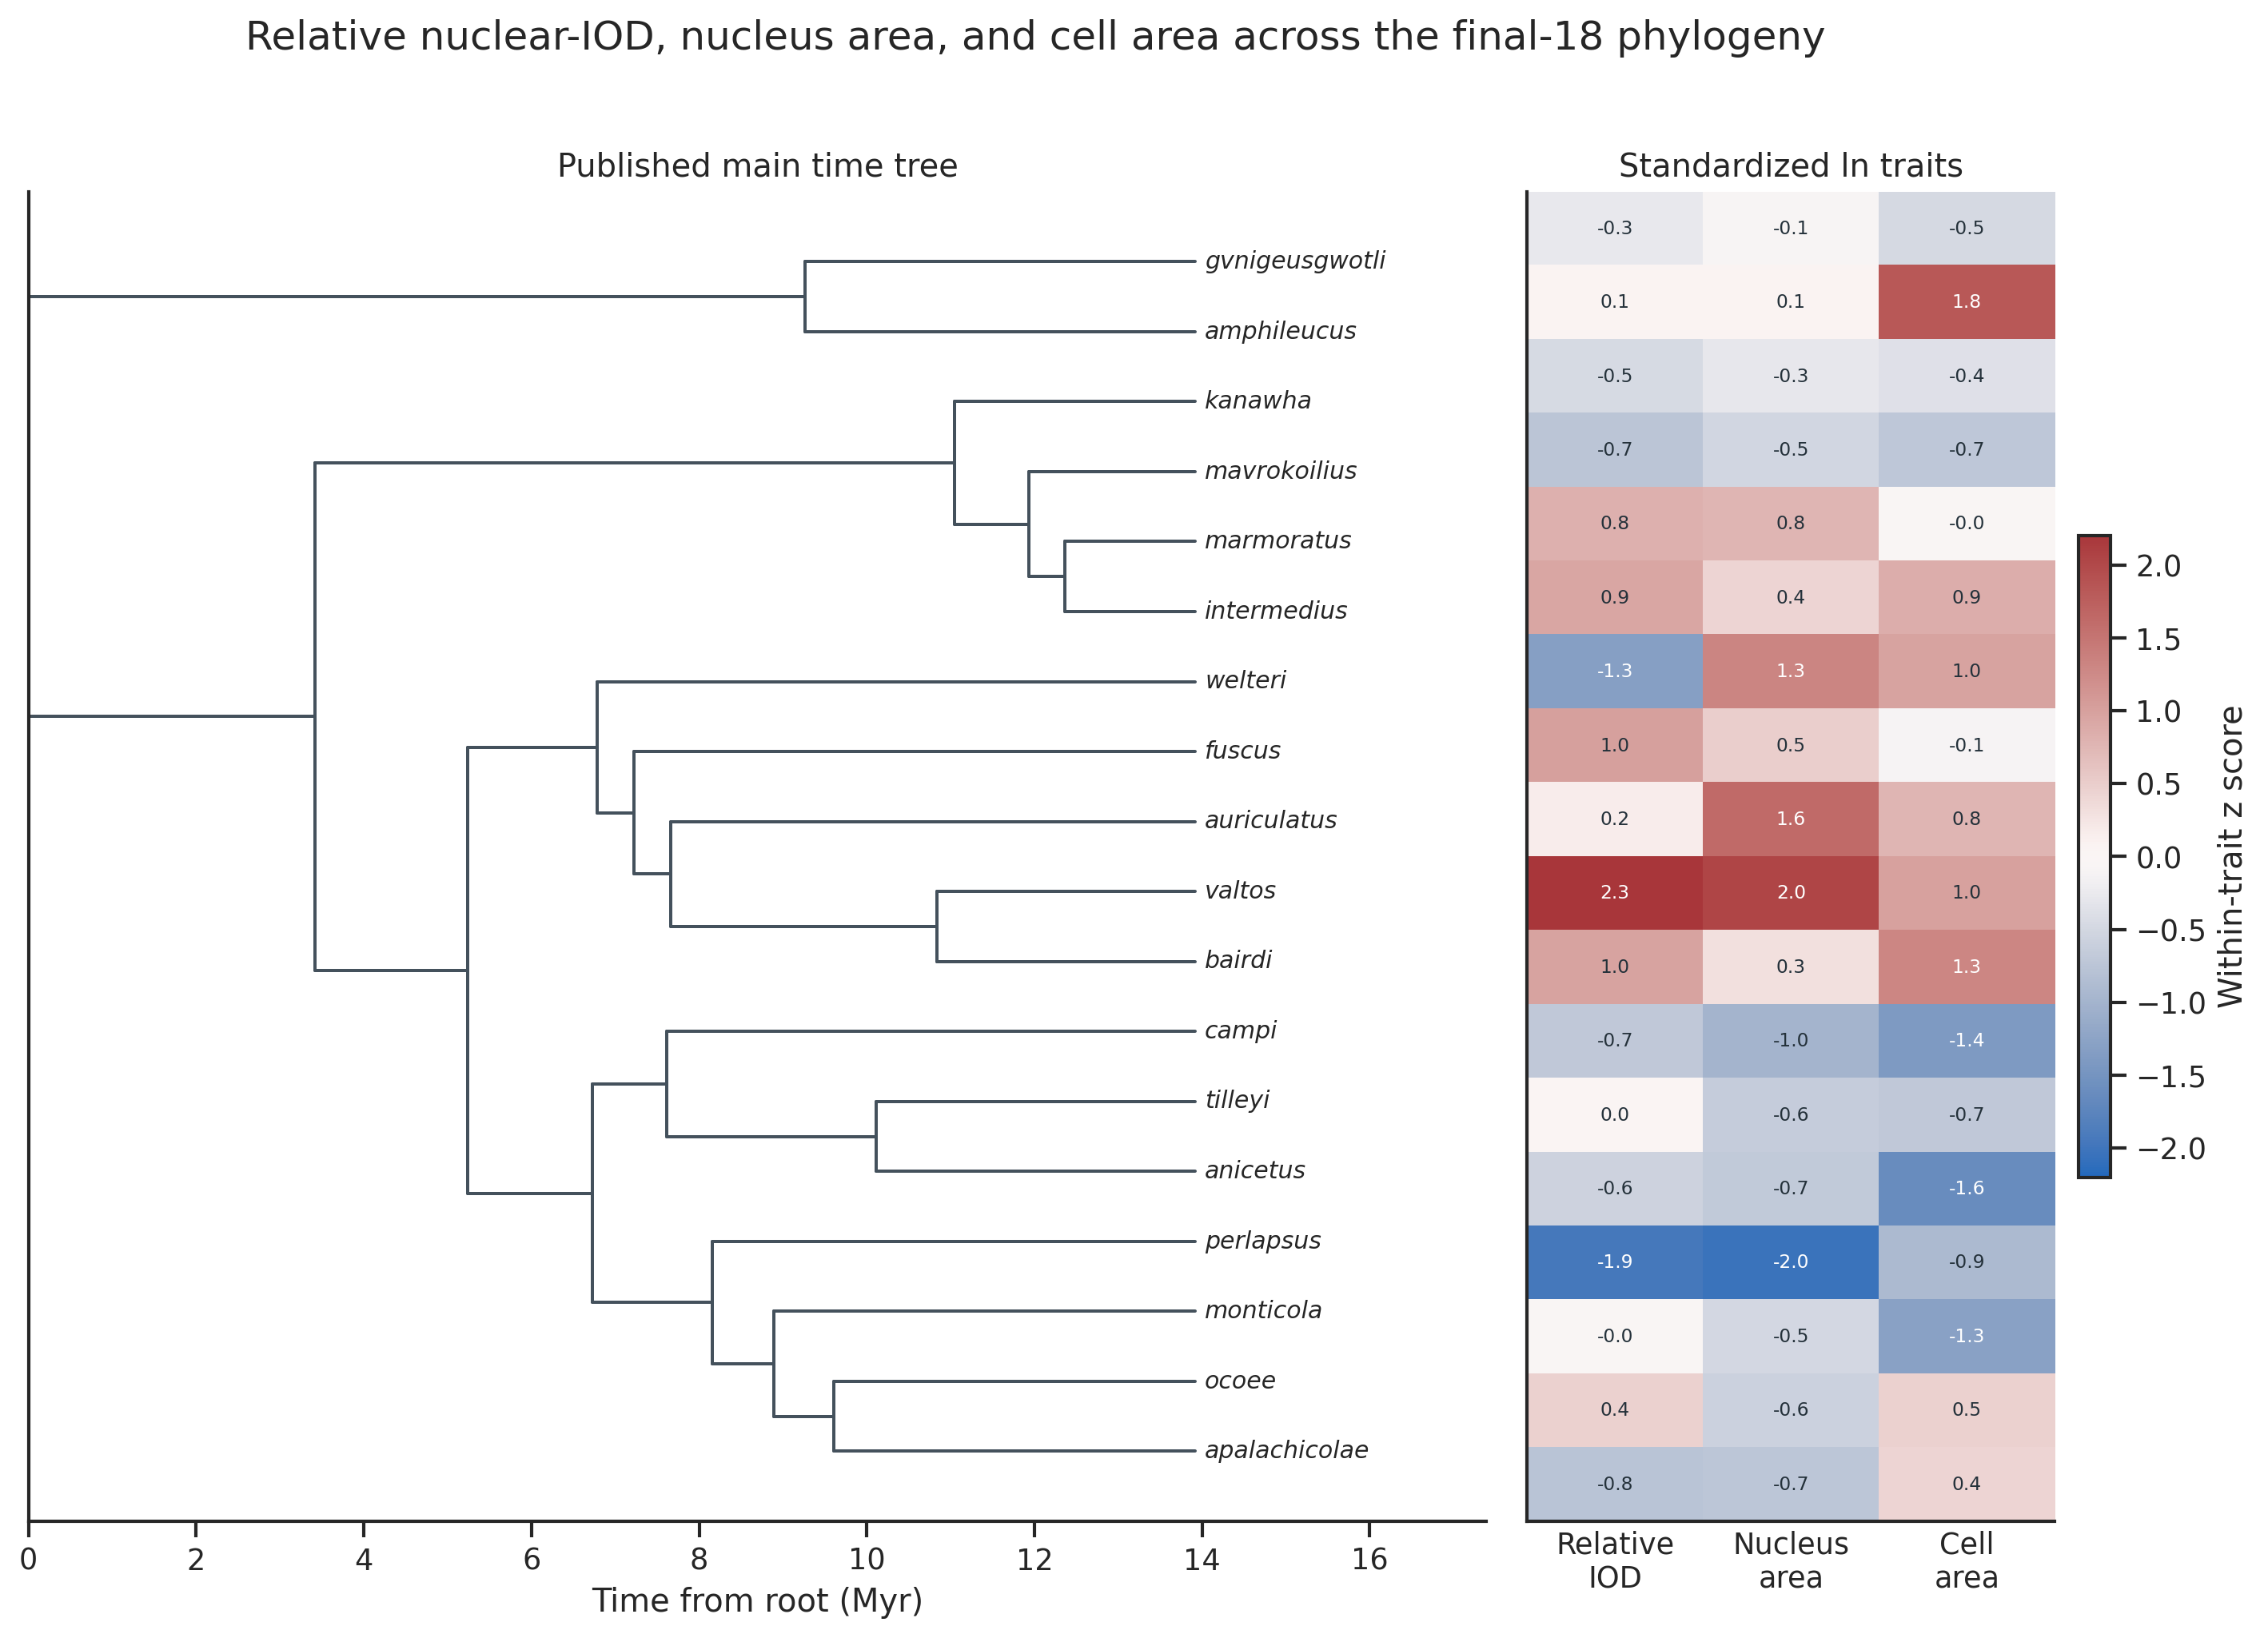

In [6]:
show_figure("results/figures/presentation_notebooks/cell_models/cell_trait_pairwise_bm_pgls_analysis18_v1.png")
show_figure("results/figures/presentation_notebooks/cell_models/cell_trait_phylogeny_tracks_analysis18_v1.png")

## Relative nuclear-IOD quality and dependence checks

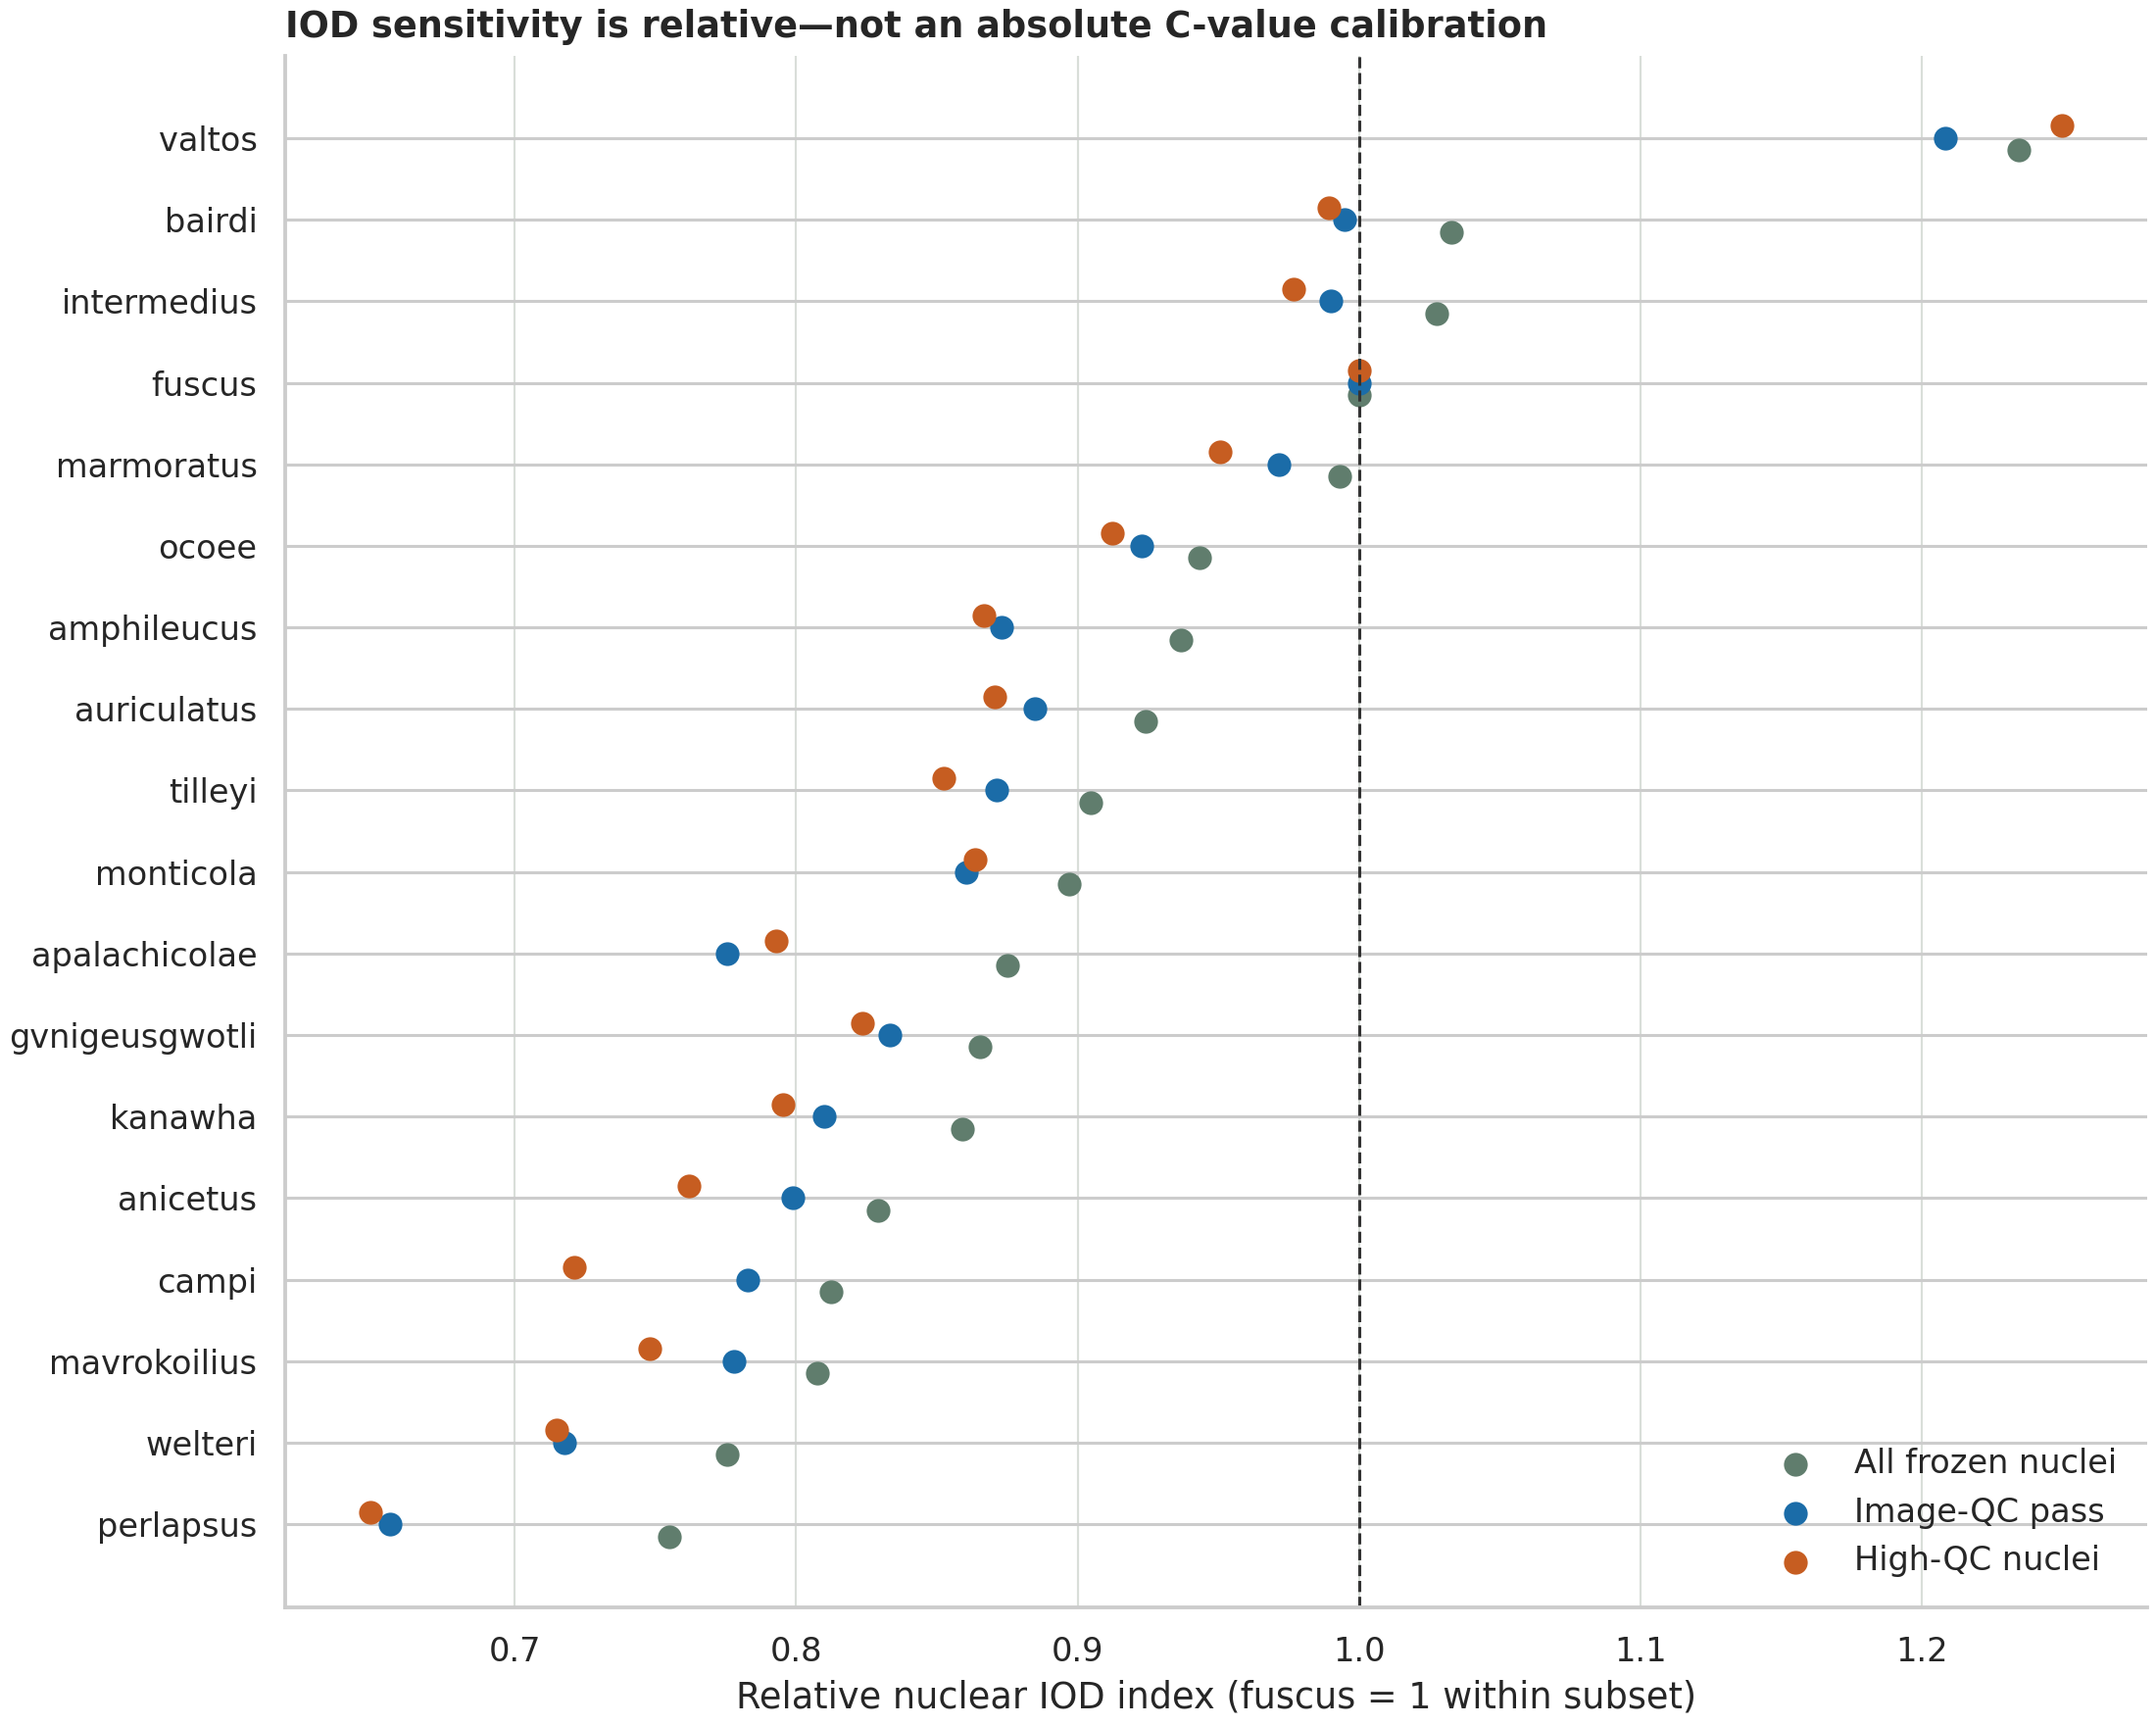

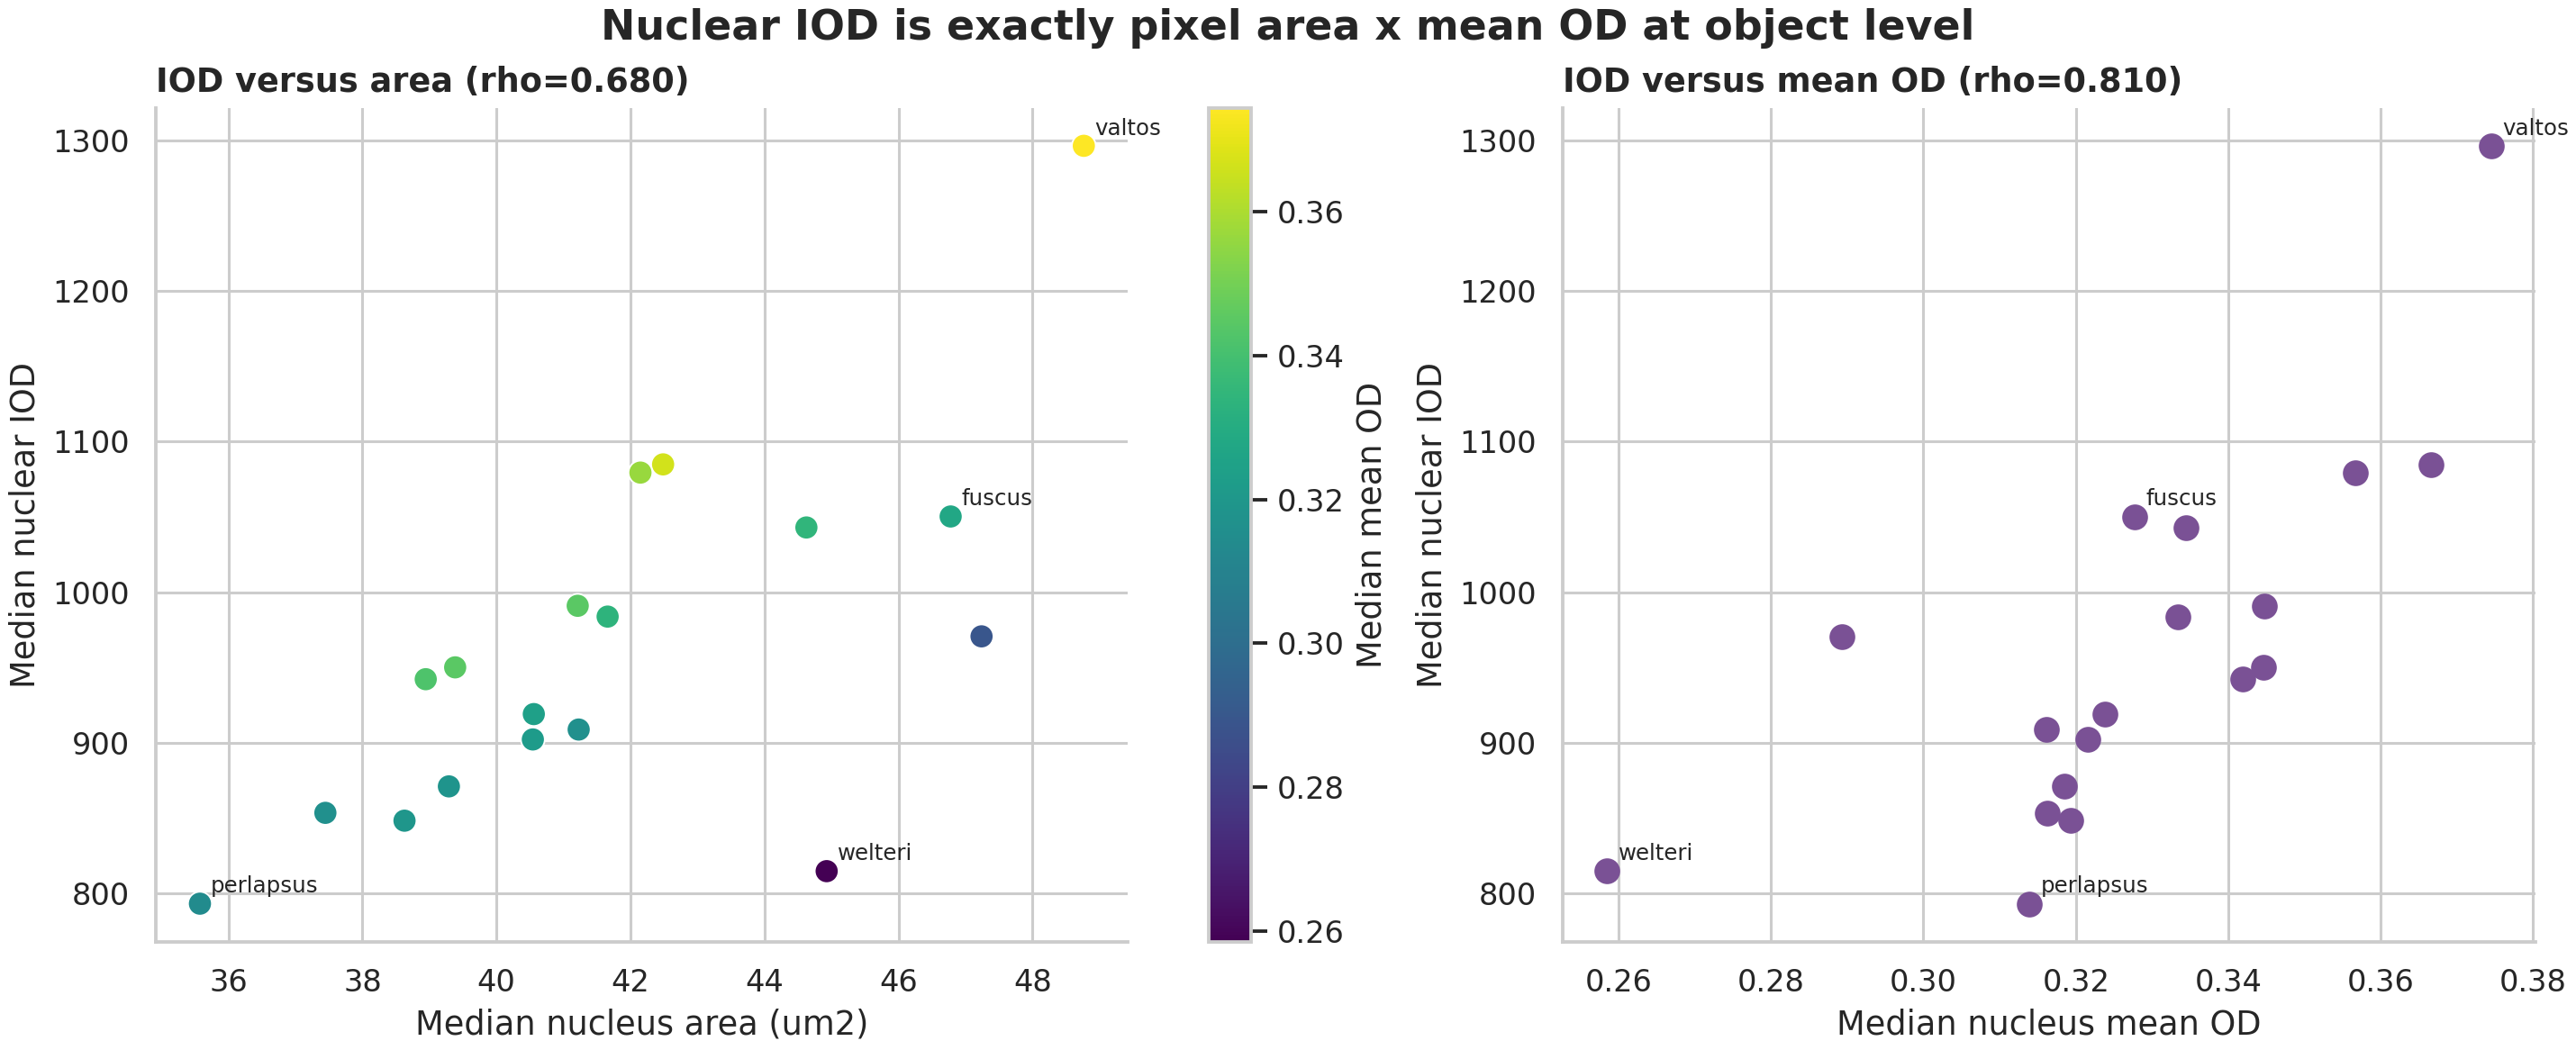

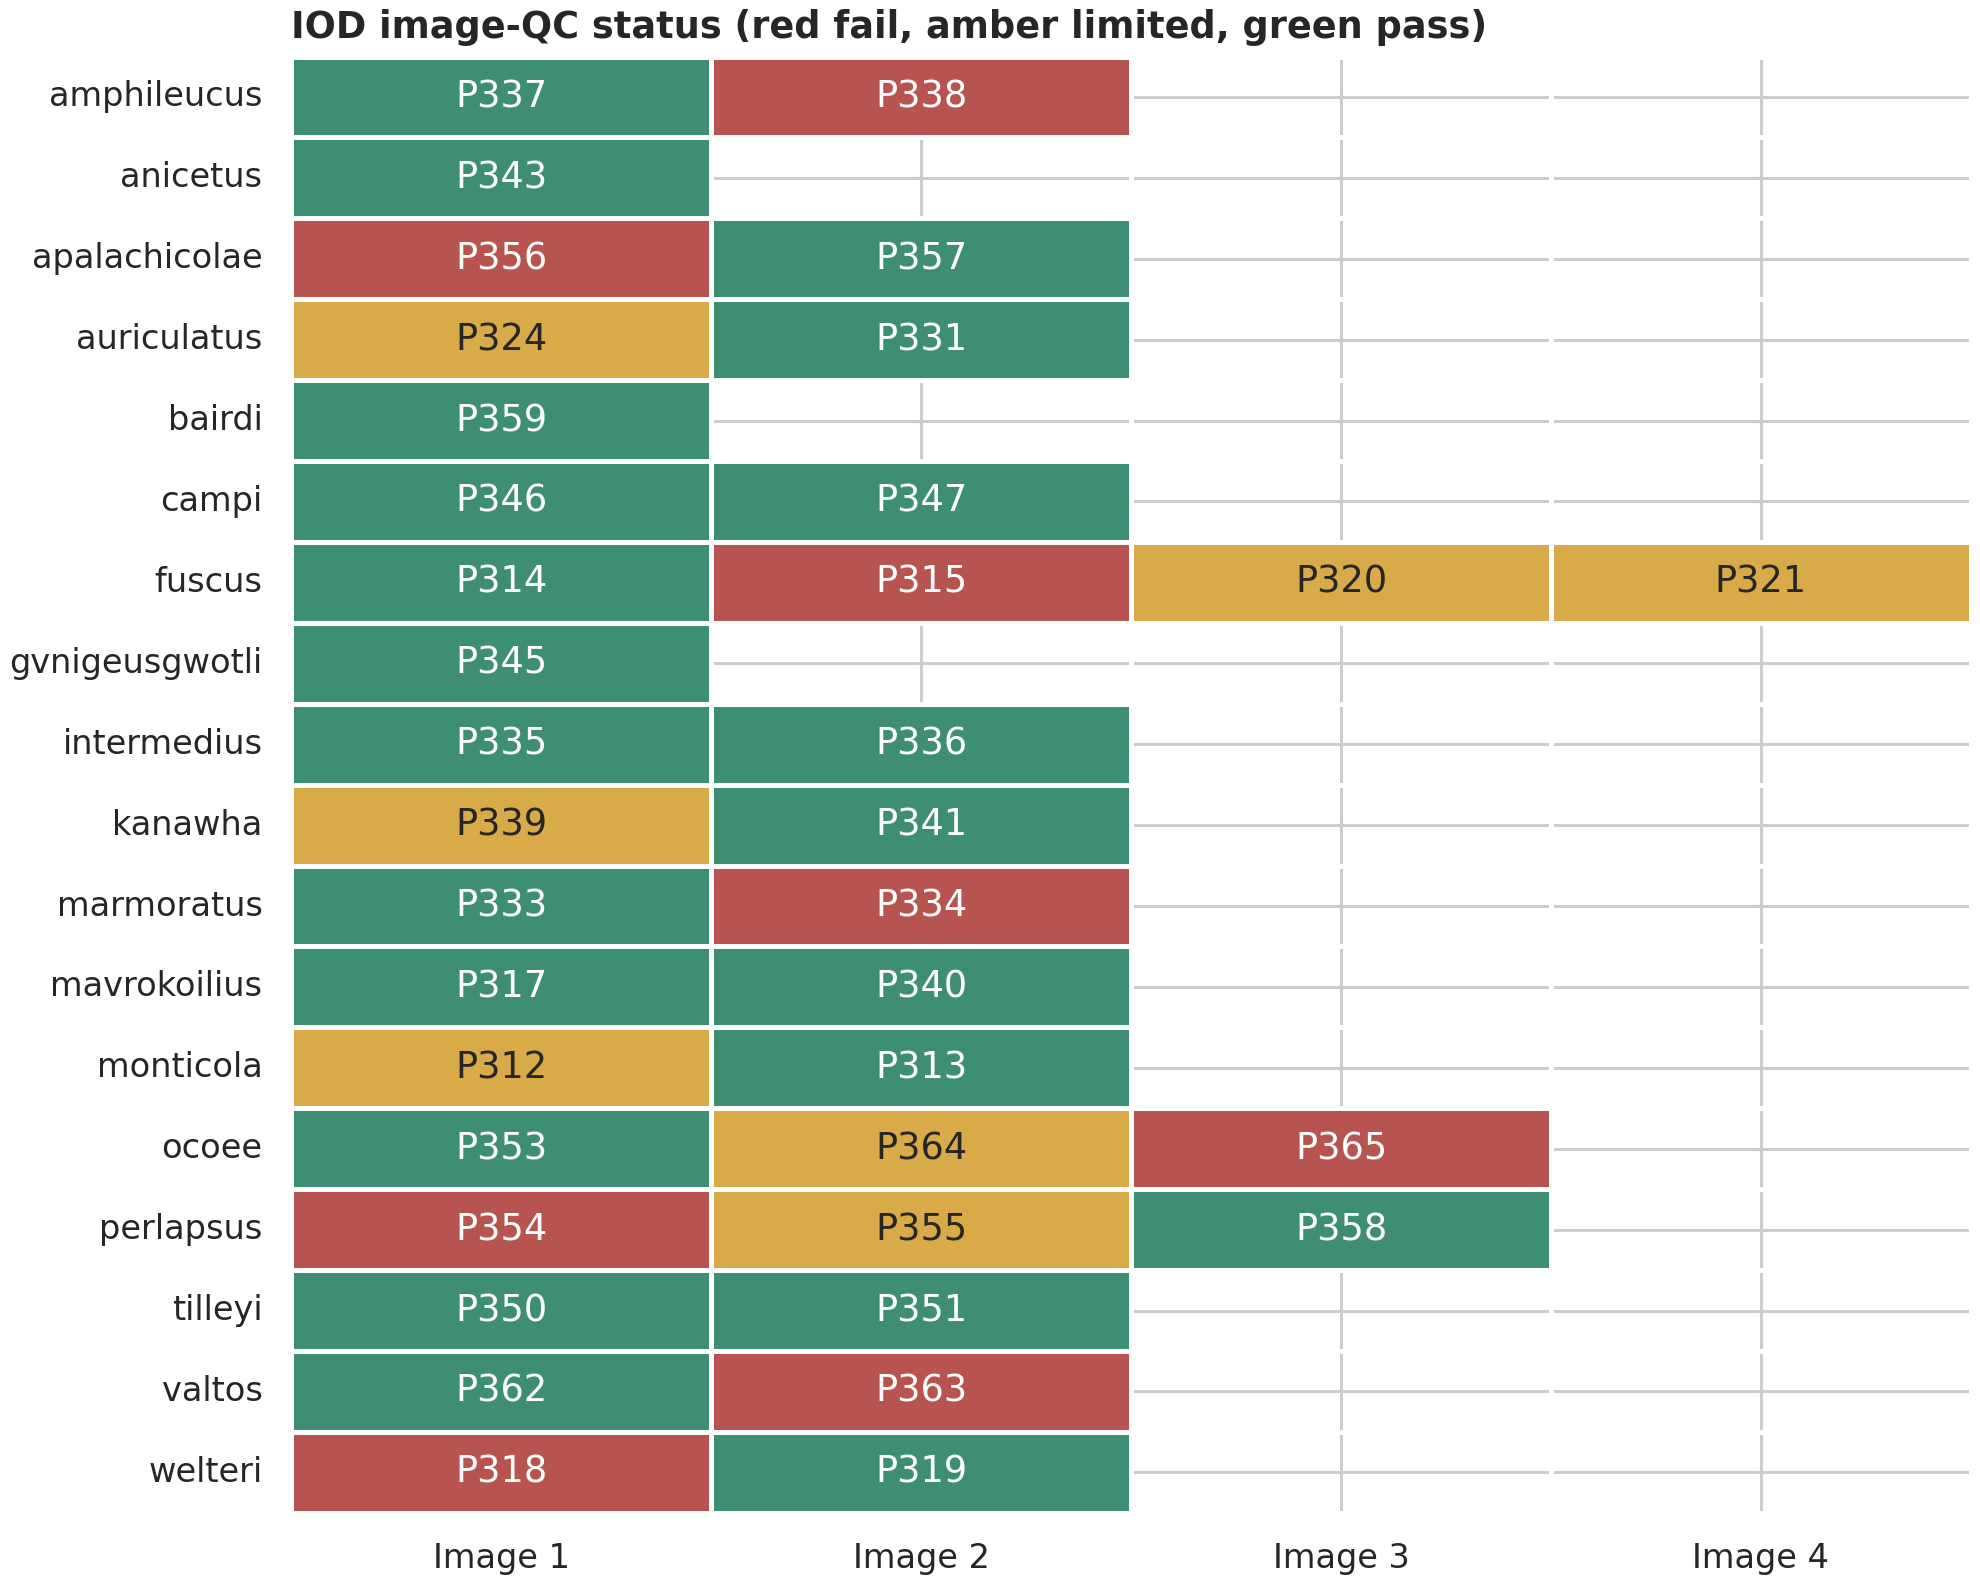

In [7]:
for figure in [
    "results/figures/corrected/microscopy/microscopy_relative_iod_qc_sensitivity_analysis18_v1.png",
    "results/figures/corrected/microscopy/microscopy_iod_decomposition_analysis18_v1.png",
    "results/figures/corrected/microscopy/microscopy_image_iod_qc_analysis18_v1.png",
]:
    show_figure(figure)

In [8]:
source_files = pd.DataFrame([{'role': 'Cell21 frozen builder', 'path': 'scripts/processing/build_cell21_descriptive_bundle.py'}, {'role': 'microscopy release audit', 'path': 'scripts/processing/audit_microscopy_release.py'}, {'role': 'largest-cell mask review builder', 'path': 'path_analysis/scripts/build_largest_cell_mask_review.py'}, {'role': 'CellProfiler provenance audit', 'path': 'path_analysis/CELLPROFILER_PROVENANCE_AUDIT.md'}])
source_files["resolved_path"] = source_files.path.map(lambda value: str(resolve_artifact(value).relative_to(ROOT)))
source_files["exists"] = source_files.path.map(lambda value: resolve_artifact(value).exists())
display(source_files)
if not source_files.exists.all():
    raise FileNotFoundError(source_files.loc[~source_files.exists, "path"].tolist())

,role,path,resolved_path,exists
0,Cell21 frozen builder,scripts/processing/build_cell21_descriptive_bundle.py,scripts/processing/build_cell21_descriptive_bundle.py,True
1,microscopy release audit,scripts/processing/audit_microscopy_release.py,scripts/processing/audit_microscopy_release.py,True
2,largest-cell mask review builder,path_analysis/scripts/build_largest_cell_mask_review.py,path_analysis/scripts/build_largest_cell_mask_review.py,True
3,CellProfiler provenance audit,path_analysis/CELLPROFILER_PROVENANCE_AUDIT.md,path_analysis/CELLPROFILER_PROVENANCE_AUDIT.md,True


## Interpretation and review boundary

- Cell21 is the descriptive denominator; path18 is used only for explicitly
  comparative plots.
- The selected-50 statistic is a quality-screened upper-tail morphology estimand,
  not a literal largest-50 sort or a species-typical erythrocyte estimate.
- Existing segmentation validation is diagnostic and does not establish held-out
  generalization across all focal species.
- Relative nuclear-IOD cannot be presented as picograms, C-value, or an independent
  validation of genome size.